# Carregamento do DataSet

In [1]:
%reload_ext autoreload
%autoreload 2

from variables import filenames, features, target
from load_dataset import load
from pre_processing import apply
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = load(filenames)
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# Preprocessamento

## Substituindo valores faltantes pela media

In [51]:
apply(df)

Quantidade de valores alterados:  3128


# Analise do Dataset

In [52]:
df.columns = df.columns.str.strip()
df.drop(columns=["Destination Port"], inplace=True)
#select_colums = ["Destination Port", "Total Fwd Packets", "Total Backward Packets", "Total Length of Fwd Packets", "Total Length of Bwd Packets", "Flow Duration", "Flow Packets/s", "Flow Bytes/s", "Down/Up Ratio", "Label"]
#df = df[select_colums]
df.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,109,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,52,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,34,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [20]:
df.columns

Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PS

In [ ]:
# Muda os ataques para categorias mais genéricas, para facilitar a visualização e o entendimento dos dados
#print("Unique labels before mapping:", df['Label'].unique())
#attack_mapping = {
#    'BENIGN': 'Benign',
#    'DDoS': 'DDoS',
#    'PortScan': 'Port Scan',
#    'Bot': 'Bot',
#    'Infiltration': 'Infiltration',
#    'Web Attack � Brute Force': 'Web Attack',
#    'Web Attack � XSS': 'Web Attack',
#    'Web Attack � Sql Injection': 'Web Attack',
#    'FTP-Patator': 'Bruteforce',
#    'SSH-Patator': 'Bruteforce',
#    'DoS slowloris': 'DoS',
#    'DoS Slowhttptest': 'DoS',
#    'DoS Hulk': 'DoS',
#    'DoS GoldenEye': 'DoS',
#    'Heartbleed': 'Heartbleed'
#}
#
#df['Label'] = df['Label'].map(attack_mapping)
#print("\n\nUnique labels after mapping:", df['Label'].unique())


In [53]:
df = df[df['Label'].isin(['BENIGN', 'DDoS', 'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye'])]
df['Label'].value_counts()

Label
BENIGN              2096484
DoS Hulk             172849
DDoS                 128016
DoS GoldenEye         10286
DoS slowloris          5385
DoS Slowhttptest       5228
Name: count, dtype: int64

In [54]:
df_slowloris = df[df['Label'] == 'DoS slowloris']
df_slowloris.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
6558,5169956,8,6,1101,4222,410,0,137.625,185.758628,3525,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DoS slowloris
26700,229,2,0,12,0,6,6,6.000,0.000000,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DoS slowloris
26701,5001928,3,1,12,0,6,0,4.000,3.464102,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DoS slowloris
26702,5125872,8,7,1659,2514,467,0,207.375,221.278065,1047,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DoS slowloris
26703,214,2,0,12,0,6,6,6.000,0.000000,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DoS slowloris


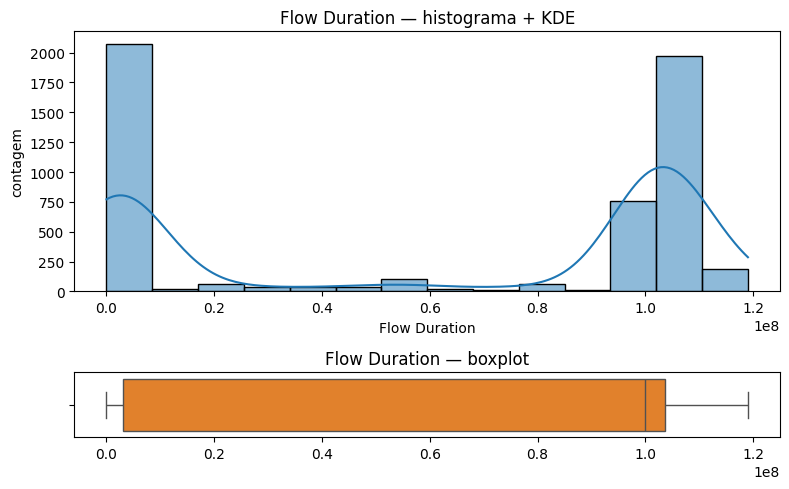

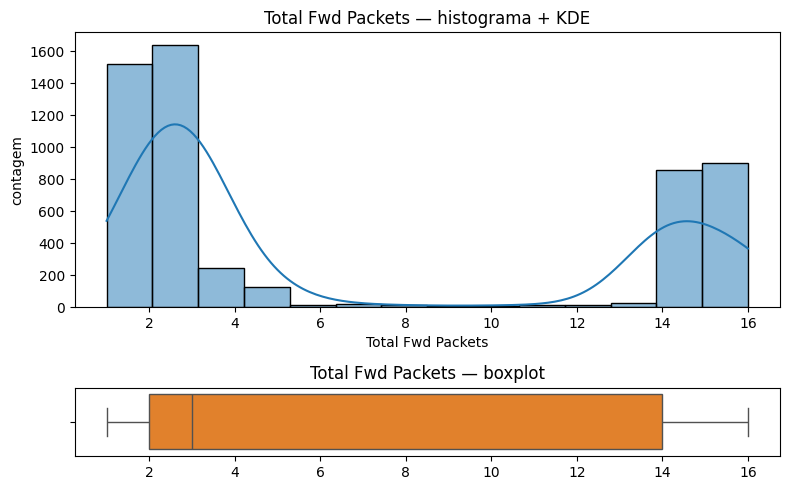

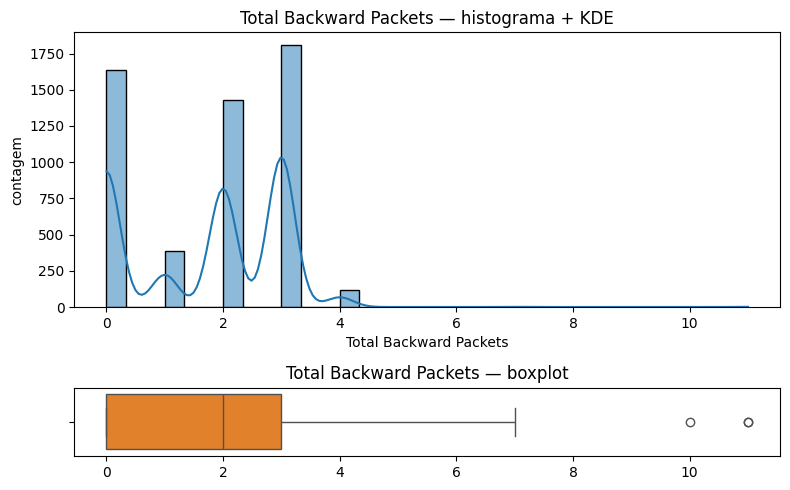

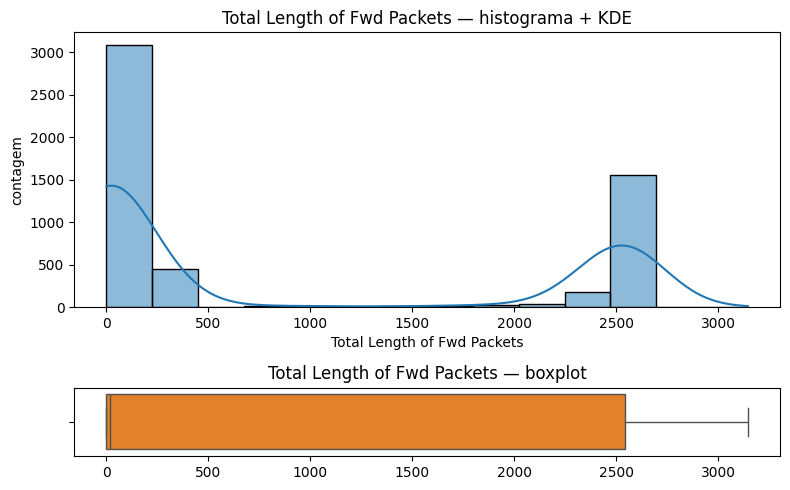

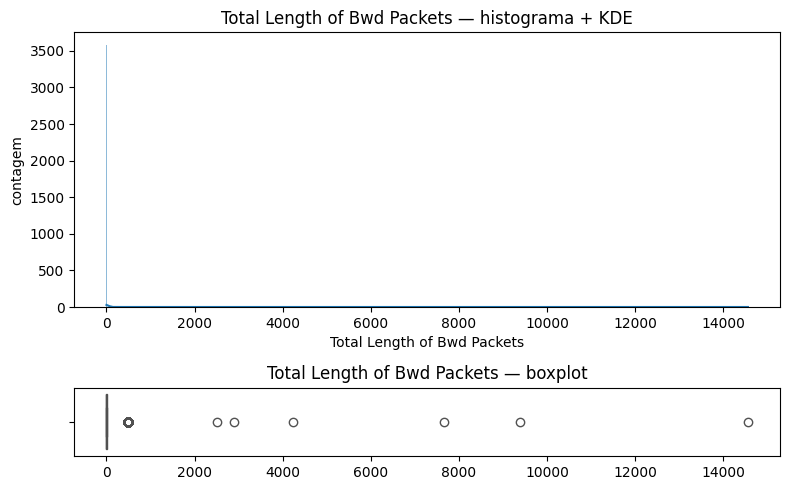

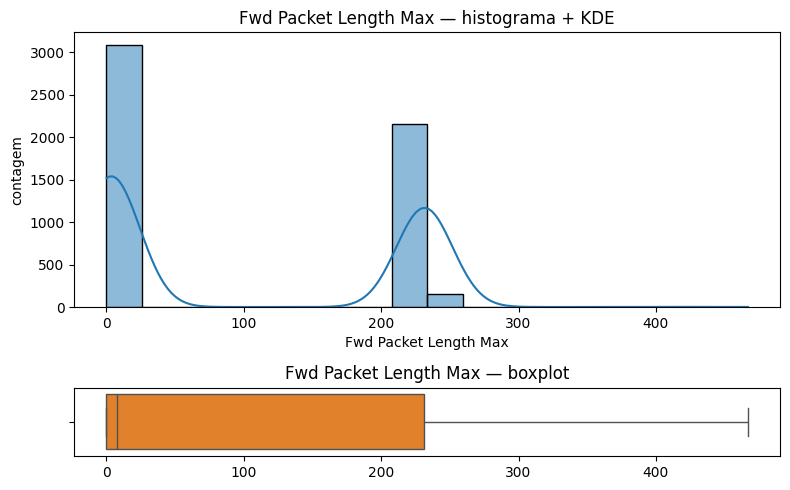

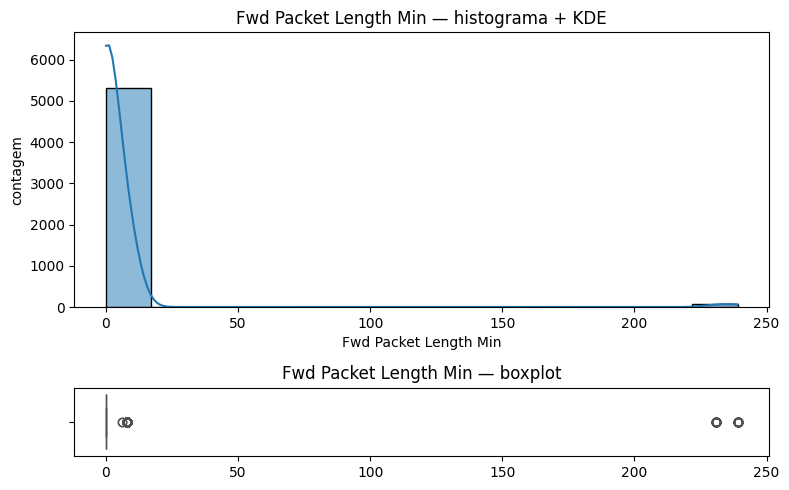

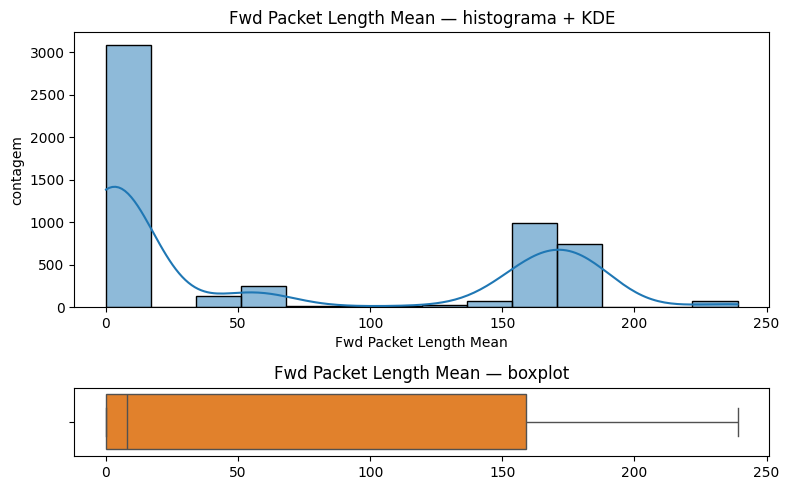

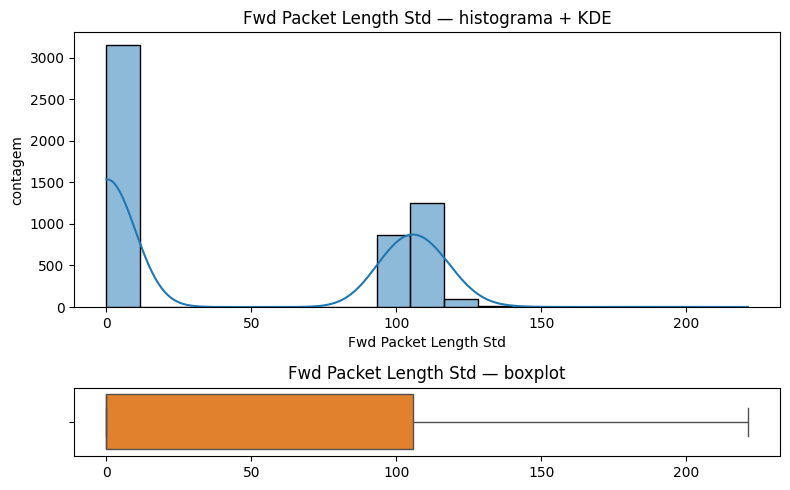

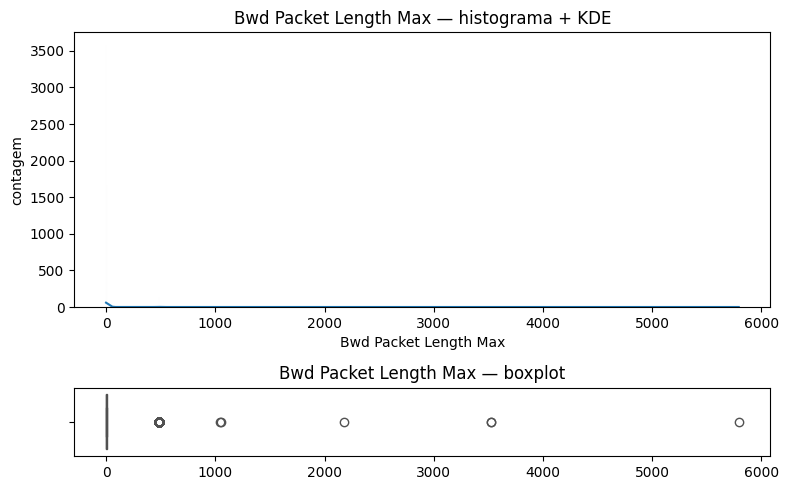

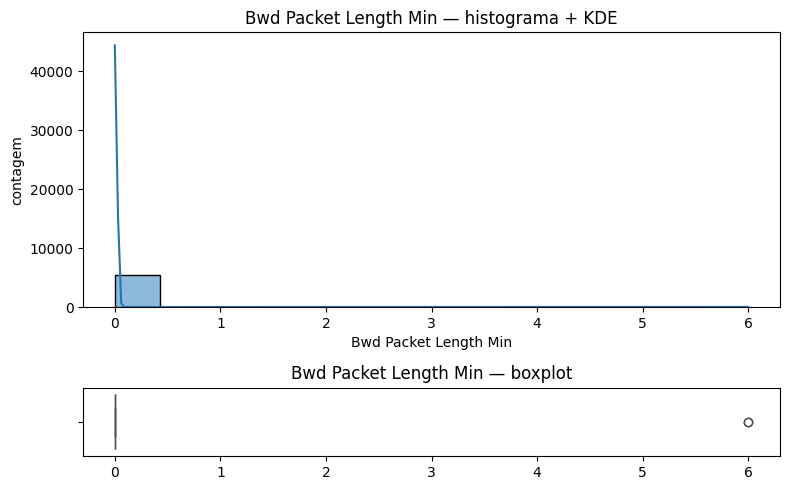

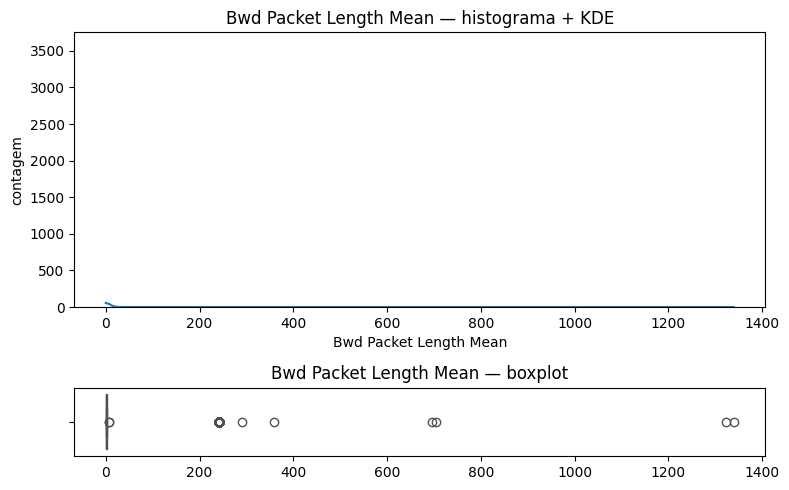

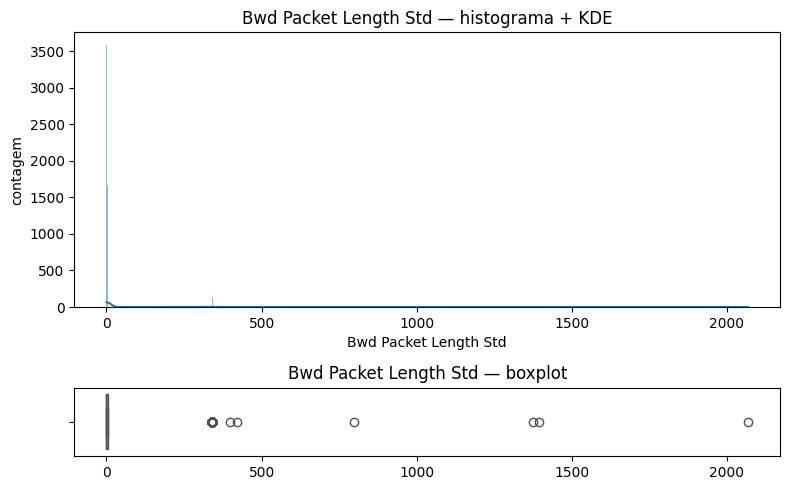

In [ ]:
import os
import seaborn as sns

import matplotlib.pyplot as plt

# Colunas numéricas (exclui constantes)
numeric_cols = df_slowloris.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if df_slowloris[c].nunique(dropna=True) > 1]

# Gera um PNG por coluna: histograma com KDE + boxplot
for col in numeric_cols:
    vals = df_slowloris[col].dropna()
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), gridspec_kw={"height_ratios": [4, 1]})
    sns.histplot(vals, kde=True, ax=axes[0], color="C0")
    axes[0].set_title(f"{col} — histograma + KDE")
    axes[0].set_ylabel("contagem")
    sns.boxplot(x=vals, ax=axes[1], color="C1")
    axes[1].set_title(f"{col} — boxplot")
    axes[1].set_xlabel("")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


In [10]:
# Gera métricas por coluna e salva em CSV
metricas_df_slowloris = df_slowloris.describe(include="all").T

metricas_df_slowloris["dtype"] = df_slowloris.dtypes.astype(str)
metricas_df_slowloris["non_null"] = df_slowloris.notna().sum()
metricas_df_slowloris["null_count"] = df_slowloris.isna().sum()
metricas_df_slowloris["null_pct"] = (df_slowloris.isna().mean() * 100).round(4)
metricas_df_slowloris["n_unique"] = df_slowloris.nunique(dropna=True)

# Reorganiza colunas para facilitar leitura
ordem = ["mean", "std", "min", "25%", "50%", "75%", "max", ]
metricas_df_slowloris = metricas_df_slowloris[[c for c in ordem if c in metricas_df_slowloris.columns]]

# Salva arquivo
arquivo_saida = "metricas_df_slowloris.csv"
metricas_df_slowloris.to_csv(arquivo_saida, encoding="utf-8-sig")

print(f"CSV gerado com sucesso: {arquivo_saida}")
metricas_df_slowloris.head()

CSV gerado com sucesso: metricas_df_slowloris.csv


,mean,std,min,25%,50%,75%,max
Flow Duration,60831953.267595,48755836.603611,2.0,3002789.0,99999406.0,103580645.0,119046064.0
Total Fwd Packets,6.74299,5.766769,1.0,2.0,3.0,14.0,16.0
Total Backward Packets,1.705478,1.295988,0.0,0.0,2.0,3.0,11.0
Total Length of Fwd Packets,871.831755,1165.884568,0.0,0.0,16.0,2541.0,3146.0
Total Length of Bwd Packets,21.888022,279.482993,0.0,0.0,0.0,6.0,14556.0


In [18]:
# Muda os ataques para categorias mais genéricas, para facilitar a visualização e o entendimento dos dados
print("Unique labels before mapping:", df['Label'].unique())
attack_mapping = {
    'BENIGN': 'Benign',
    'DDoS': 'DDoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS'
}

df['Label'] = df['Label'].map(attack_mapping)
print("\n\nUnique labels after mapping:", df['Label'].unique())

Unique labels before mapping: ['BENIGN' 'DDoS' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk'
 'DoS GoldenEye']


Unique labels after mapping: ['Benign' 'DDoS' 'DoS']


In [19]:
df['Label'].value_counts()

Label
Benign    2096484
DoS        193748
DDoS       128016
Name: count, dtype: int64

In [51]:
def plot_medias_por_classe(df, class_col="Label"):
    medias = df.groupby(class_col).mean(numeric_only=True)
    cols = medias.columns
    n = len(cols)

    for i in range(0, n, 2):
        fig, axs = plt.subplots(1, 2, figsize=(18, 3))
        for j in range(2):
            if i + j < n:
                axs[j].bar(medias.index.astype(str), medias[cols[i + j]])
                axs[j].set_title(f"Média da feature '{cols[i + j]}' por classe")
                axs[j].set_xlabel("Class")
                axs[j].set_ylabel("Média")
        plt.tight_layout()
        plt.show()

plot_medias_por_classe(df)

KeyError: 'Label'

In [20]:
# Variância de todas as colunas numéricas
cols = df.columns.drop("Label", errors="ignore")
variancias = df[cols].select_dtypes(include=np.number).var().sort_values()

# Lista das colunas com variância 0 (ou muito próxima de 0)
colunas_variancia_zero = variancias[np.isclose(variancias, 0.0)].index.tolist()

print("\nColunas com variância igual a 0 (ou muito próxima de 0):")
print(colunas_variancia_zero)

# Remove essas colunas do DataFrame
df = df.drop(columns=colunas_variancia_zero, errors="ignore")
print(f"\nTotal de colunas removidas: {len(colunas_variancia_zero)}")


Colunas com variância igual a 0 (ou muito próxima de 0):
['Fwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Fwd Avg Packets/Bulk', 'Bwd Avg Bytes/Bulk', 'Fwd Avg Bulk Rate', 'Bwd URG Flags', 'Bwd PSH Flags']

Total de colunas removidas: 8


Colunas alvo presentes no DataFrame: ['Fwd Header Length', 'Bwd Header Length', 'min_seg_size_forward']
Colunas alvo ausentes no DataFrame: ['Fwd Header Length.1']


,coluna,total_validos,qtd_negativos,%_negativos,min,p1,p50,p99,max
0,Fwd Header Length,2522362,35,0.0014%,-32212234632.0000,20.0000,64.0000,1392.0000,4644908.0000
2,min_seg_size_forward,2522362,35,0.0014%,-536870661.0000,20.0000,20.0000,40.0000,138.0000
1,Bwd Header Length,2522362,22,0.0009%,-1073741320.0000,0.0000,40.0000,1672.0000,5838440.0000


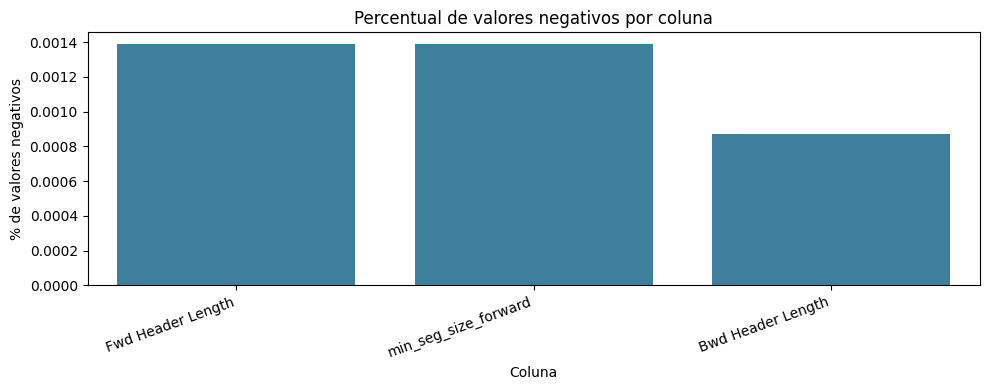

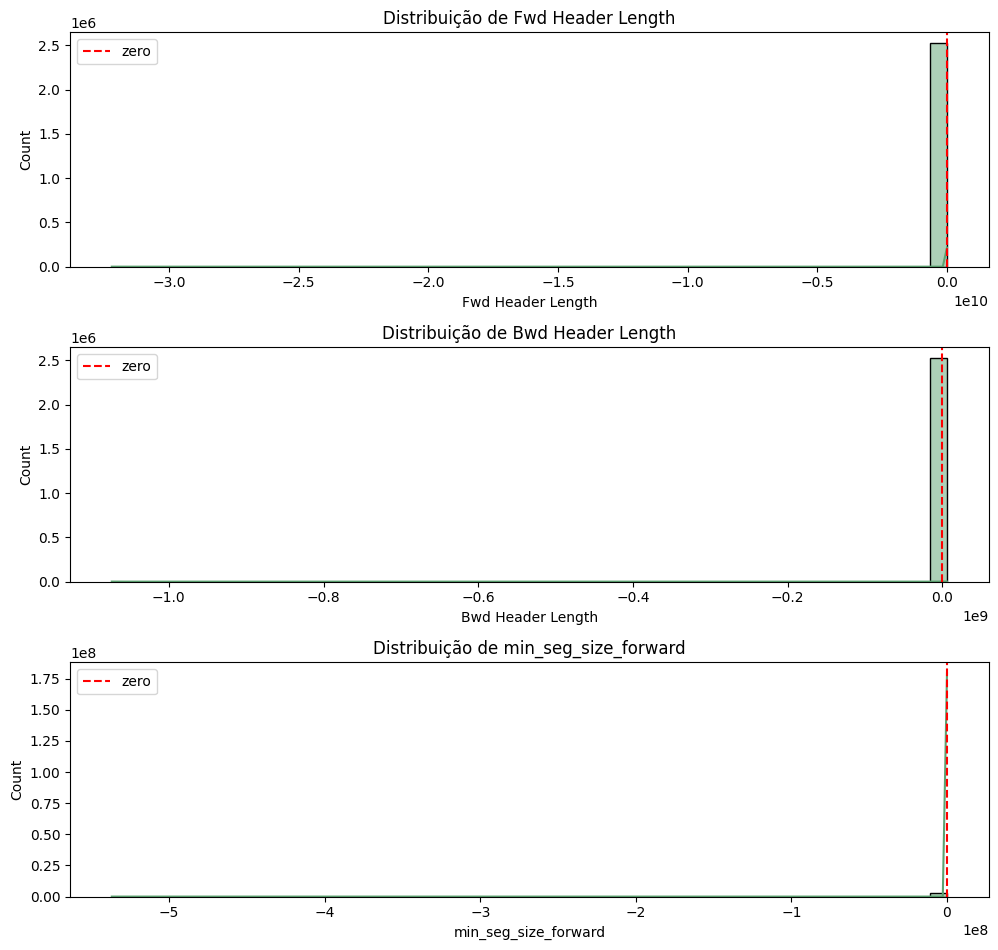


Distribuição dos negativos por Label (top 10):

Fwd Header Length -> classes/rótulos com mais negativos:
Label
Benign    35
Name: count, dtype: int64

Bwd Header Length -> classes/rótulos com mais negativos:
Label
Benign    22
Name: count, dtype: int64

min_seg_size_forward -> classes/rótulos com mais negativos:
Label
Benign    35
Name: count, dtype: int64

Exemplos mais negativos (5 linhas por coluna):

Fwd Header Length:


,Fwd Header Length
1267,-32212234632
292,-9663668122
334215,-6442447920
392300,-6442447920
1268,-4831831506



Bwd Header Length:


,Bwd Header Length
281248,-1073741320
282835,-1073741320
292036,-1073741320
283,-1073741218
295,-1073740992



min_seg_size_forward:


,min_seg_size_forward
283,-536870661
292,-536870661
295,-536870660
1267,-536870660
1268,-536870660


In [ ]:
colunas_negativas_alvo = [
    "Fwd Header Length",
    "Bwd Header Length",
    "Fwd Header Length.1",
    "min_seg_size_forward",
]

colunas_presentes = [c for c in colunas_negativas_alvo if c in df.columns]
colunas_ausentes = [c for c in colunas_negativas_alvo if c not in df.columns]

print("Colunas alvo presentes no DataFrame:", colunas_presentes)
if colunas_ausentes:
    print("Colunas alvo ausentes no DataFrame:", colunas_ausentes)

if not colunas_presentes:
    print("Nenhuma das colunas informadas está disponível em df para análise.")
else:
    resumo = []
    for col in colunas_presentes:
        s = pd.to_numeric(df[col], errors="coerce")
        validos = s.notna()
        negativos = s < 0

        total_validos = int(validos.sum())
        qtd_negativos = int((negativos & validos).sum())
        pct_negativos = (qtd_negativos / total_validos * 100) if total_validos else 0.0

        resumo.append({
            "coluna": col,
            "total_validos": total_validos,
            "qtd_negativos": qtd_negativos,
            "%_negativos": pct_negativos,
            "min": s.min(),
            "p1": s.quantile(0.01),
            "p50": s.quantile(0.50),
            "p99": s.quantile(0.99),
            "max": s.max(),
        })

    resumo_df = pd.DataFrame(resumo).sort_values("%_negativos", ascending=False)
    display(
        resumo_df.style.format({
            "%_negativos": "{:.4f}%",
            "min": "{:.4f}",
            "p1": "{:.4f}",
            "p50": "{:.4f}",
            "p99": "{:.4f}",
            "max": "{:.4f}",
        })
    )

    # Gráfico 1: percentual de negativos por coluna
    plt.figure(figsize=(10, 4))
    sns.barplot(data=resumo_df, x="coluna", y="%_negativos", color="#2E86AB")
    plt.xticks(rotation=20, ha="right")
    plt.ylabel("% de valores negativos")
    plt.xlabel("Coluna")
    plt.title("Percentual de valores negativos por coluna")
    plt.tight_layout()
    plt.show()

    # Gráfico 2: distribuição de cada coluna com linha de referência no zero
    n_cols = len(colunas_presentes)
    fig, axes = plt.subplots(n_cols, 1, figsize=(10, 3.2 * n_cols))
    if n_cols == 1:
        axes = [axes]

    for ax, col in zip(axes, colunas_presentes):
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        sns.histplot(s, bins=50, kde=True, ax=ax, color="#5DA271")
        ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="zero")
        ax.set_title(f"Distribuição de {col}")
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Análise por classe/rótulo: onde os negativos aparecem com mais frequência
    coluna_classe = None
    if "Label" in df.columns:
        coluna_classe = "Label"
    elif "Class" in df.columns:
        coluna_classe = "Class"

    if coluna_classe is not None:
        print(f"\nDistribuição dos negativos por {coluna_classe} (top 10):")
        for col in colunas_presentes:
            s = pd.to_numeric(df[col], errors="coerce")
            temp = df.loc[s < 0, [coluna_classe, col]].copy()
            if temp.empty:
                print(f"\n{col}: sem valores negativos")
                continue

            dist = temp[coluna_classe].value_counts().head(10)
            print(f"\n{col} -> classes/rótulos com mais negativos:")
            print(dist)

    # Exemplos extremos para inspeção manual
    print("\nExemplos mais negativos (5 linhas por coluna):")
    for col in colunas_presentes:
        s = pd.to_numeric(df[col], errors="coerce")
        amostra = df.loc[s < 0, [col]].copy()
        if amostra.empty:
            print(f"\n{col}: sem negativos")
            continue
        print(f"\n{col}:")
        display(amostra.nsmallest(5, col))

In [21]:
col1, col2 = "Fwd Header Length", "Fwd Header Length.1"

if col1 not in df.columns or col2 not in df.columns:
    print(f"Coluna ausente. Disponíveis? {col1 in df.columns=}, {col2 in df.columns=}")
else:
    iguais = df[col1].equals(df[col2])  # compara considerando NaN na mesma posição como igual
    print(f"As colunas '{col1}' e '{col2}' são totalmente iguais? {iguais}")

    mask_diff = ~(df[col1].eq(df[col2]) | (df[col1].isna() & df[col2].isna()))
    qtd_diff = int(mask_diff.sum())
    total = len(df)

    print(f"Total de linhas: {total}")
    print(f"Linhas diferentes: {qtd_diff} ({(qtd_diff/total)*100:.6f}%)")

    if qtd_diff > 0:
        print("\nExemplos de diferenças:")
        display(df.loc[mask_diff, [col1, col2]].head(10))

As colunas 'Fwd Header Length' e 'Fwd Header Length.1' são totalmente iguais? True
Total de linhas: 2418248
Linhas diferentes: 0 (0.000000%)


In [26]:
#Remover a coluna "Fwd Header Length.1" por ser idêntica à "Fwd Header Length"
if "Fwd Header Length.1" in df.columns:
    df.drop(columns=["Fwd Header Length.1"], inplace=True)
    print("Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.")

In [27]:
df.columns

Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count',
       'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', '

In [14]:
# Distribuição dos dados para cada coluna numérica (em lotes, para não ficar pesado)
dados_plot = num_df.copy() if "num_df" in globals() else df.select_dtypes(include=np.number).copy()

# Amostra para acelerar a visualização (ajuste se quiser mais/menos pontos)
amostra_tam = min(100000, len(dados_plot))
dados_plot = dados_plot.sample(n=amostra_tam, random_state=42) if len(dados_plot) > amostra_tam else dados_plot

colunas = dados_plot.columns.tolist()
cols_por_linha = 4
plots_por_figura = 12  # 3 linhas x 4 colunas

for inicio in range(0, len(colunas), plots_por_figura):
    bloco = colunas[inicio:inicio + plots_por_figura]
    n = len(bloco)
    n_linhas = int(np.ceil(n / cols_por_linha))

    fig, axes = plt.subplots(n_linhas, cols_por_linha, figsize=(20, 4.2 * n_linhas))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(bloco):
        sns.histplot(dados_plot[col].dropna(), bins=50, kde=True, ax=axes[i], color="#2E86AB")
        axes[i].set_title(f"Distribuição: {col}")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Frequência")

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

KeyboardInterrupt: 

,classe,coluna,qtd_negativos,total_classe,%_na_classe
58,Benign,Init_Win_bytes_backward,1153067,2096484,55.000038
57,Benign,Init_Win_bytes_forward,911020,2096484,43.454660
18,Benign,Flow IAT Min,2688,2096484,0.128215
0,Benign,Flow Duration,107,2096484,0.005104
14,Benign,Flow Packets/s,107,2096484,0.005104
15,Benign,Flow IAT Mean,107,2096484,0.005104
17,Benign,Flow IAT Max,107,2096484,0.005104
13,Benign,Flow Bytes/s,78,2096484,0.003721
31,Benign,Fwd Header Length,35,2096484,0.001669
52,Benign,Fwd Header Length.1,35,2096484,0.001669


,classe,coluna,qtd_negativos,total_classe,%_na_classe
58,Benign,Init_Win_bytes_backward,1153067,2096484,55.000038
57,Benign,Init_Win_bytes_forward,911020,2096484,43.454660
18,Benign,Flow IAT Min,2688,2096484,0.128215
0,Benign,Flow Duration,107,2096484,0.005104
14,Benign,Flow Packets/s,107,2096484,0.005104
15,Benign,Flow IAT Mean,107,2096484,0.005104
17,Benign,Flow IAT Max,107,2096484,0.005104
13,Benign,Flow Bytes/s,78,2096484,0.003721
31,Benign,Fwd Header Length,35,2096484,0.001669
52,Benign,Fwd Header Length.1,35,2096484,0.001669


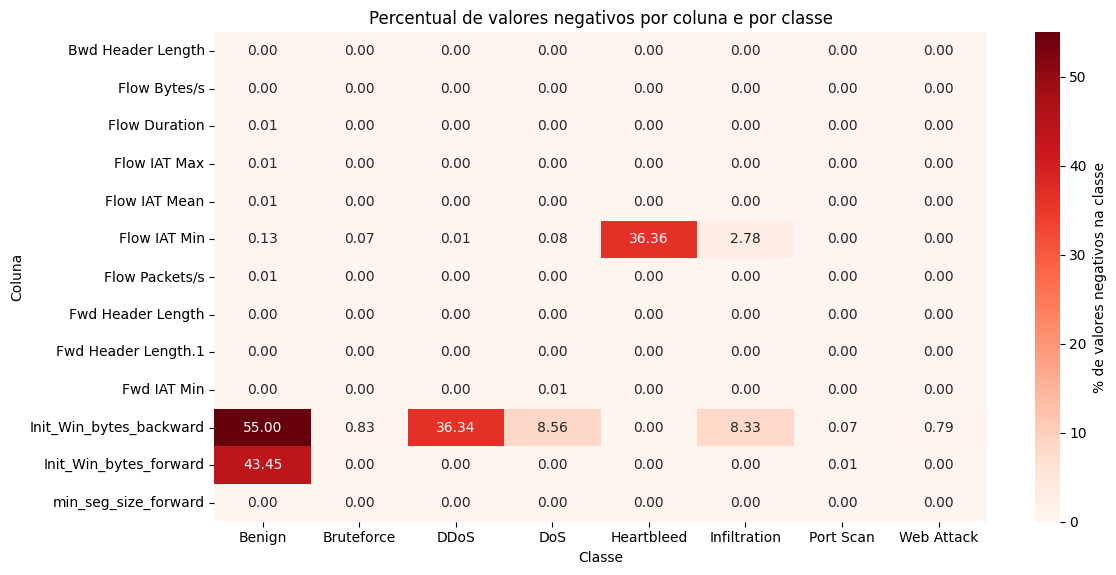

In [28]:
# Visualizar, por classe, quais colunas têm valores negativos
# e qual percentual isso representa dentro de cada classe

coluna_classe = "Label" if "Label" in df.columns else "Class"

# Colunas numéricas (excluindo a coluna de classe, se numérica)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
if coluna_classe in num_cols:
    num_cols.remove(coluna_classe)

# Máscara de negativos por coluna numérica
neg_mask = df[num_cols].lt(0)

# Quantidade de negativos por classe e por coluna
neg_counts_por_classe = neg_mask.groupby(df[coluna_classe]).sum()

# Total de linhas por classe
total_por_classe = df[coluna_classe].value_counts().sort_index()

# Percentual de negativos dentro de cada classe
pct_por_classe = neg_counts_por_classe.div(total_por_classe, axis=0).mul(100)

# Tabela detalhada (formato longo)
resultado_negativos = (
    neg_counts_por_classe.stack()
    .rename("qtd_negativos")
    .reset_index()
    .rename(columns={coluna_classe: "classe", "level_1": "coluna"})
)

resultado_negativos["total_classe"] = resultado_negativos["classe"].map(total_por_classe)
resultado_negativos["%_na_classe"] = (
    resultado_negativos["qtd_negativos"] / resultado_negativos["total_classe"] * 100
)

resultado_negativos = resultado_negativos[resultado_negativos["qtd_negativos"] > 0] \
    .sort_values(["classe", "%_na_classe"], ascending=[True, False])

display(resultado_negativos)

# Heatmap para visualização por classe x coluna
tabela_percentual = resultado_negativos.pivot(
    index="coluna",
    columns="classe",
    values="%_na_classe"
).fillna(0)

plt.figure(figsize=(12, max(4, 0.45 * len(tabela_percentual))))
sns.heatmap(
    tabela_percentual,
    cmap="Reds",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "% de valores negativos na classe"}
)
plt.title("Percentual de valores negativos por coluna e por classe")
plt.xlabel("Classe")
plt.ylabel("Coluna")
plt.tight_layout()
plt.show()

In [28]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["Class"] = label_encoder.fit_transform(df["Label"].astype(str))

mapa_classes = pd.DataFrame({
    "Label": label_encoder.classes_,
    "Class": range(len(label_encoder.classes_))
})

display(mapa_classes)

,Label,Class
0,Benign,0
1,DDoS,1
2,DoS,2


In [29]:
df.drop(columns=["Label"], inplace=True)

## Balanceamento

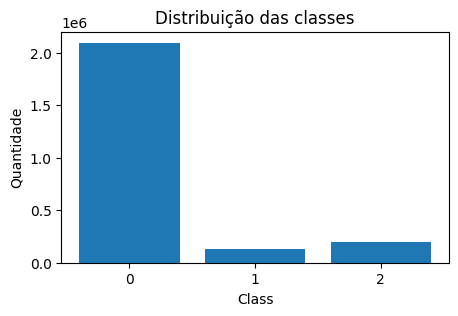

In [30]:
def plot_class_distribution(df, class_col="Class"):
    counts = df[class_col].value_counts().sort_index()
    plt.figure(figsize=(5,3))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title("Distribuição das classes")
    plt.xlabel("Class")
    plt.ylabel("Quantidade")
    plt.show()
plot_class_distribution(df)

In [31]:
classe_benign = df[df["Class"] == 0]
classe_ddos = df[df["Class"] == 1]
classe_dos = df[df["Class"] == 2]

In [32]:
df['Class'].value_counts()

Class
0    2096484
2     193748
1     128016
Name: count, dtype: int64

In [33]:
len(classe_benign), len(classe_ddos), len(classe_dos)

(2096484, 128016, 193748)

In [34]:
classe_benign = df[df["Class"] == 0]
classe_ddos = df[df["Class"] == 1]
classe_dos = df[df["Class"] == 2]


min_count = min(len(classe_benign), len(classe_ddos), len(classe_dos))

# Faz o undersample da classe maior
    
classe_benign_sample = classe_benign.sample(n=min_count, random_state=42)
classe_ddos_sample = classe_ddos.sample(n=min_count, random_state=42)
classe_dos_sample = classe_dos.sample(n=min_count, random_state=42)

# Junta as duas classes
df_undersampled = pd.concat([classe_benign_sample, classe_ddos_sample, classe_dos_sample])

# Embaralha o resultado
df_undersampled = df_undersampled.sample(frac=1, random_state=42).reset_index(drop=True)

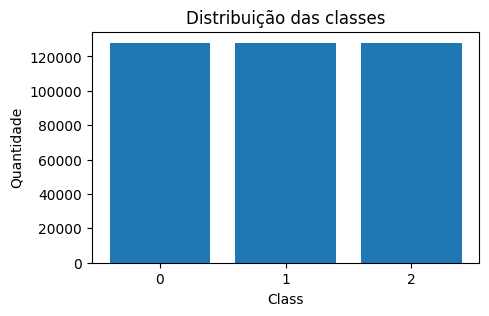

In [35]:
plot_class_distribution(df_undersampled)

## Analise dos dados apos undersampling

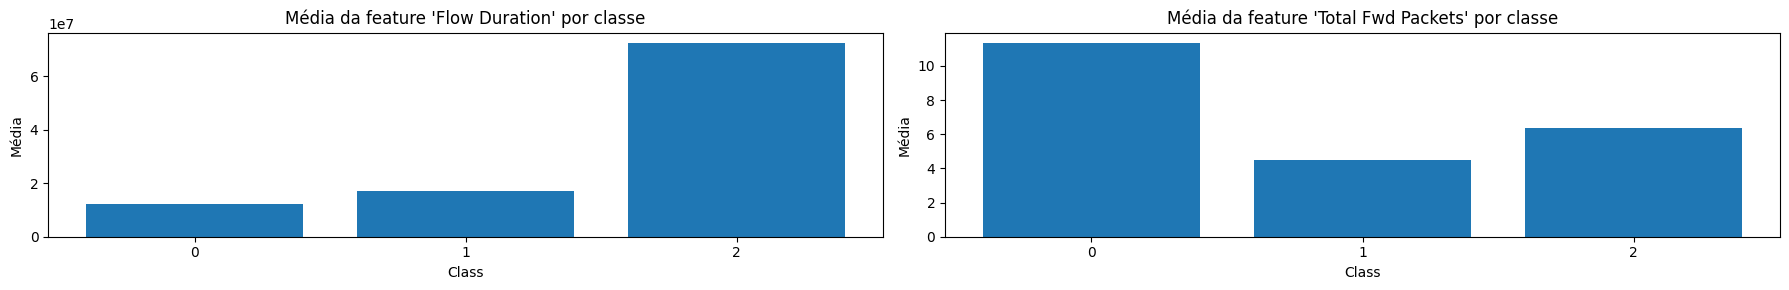

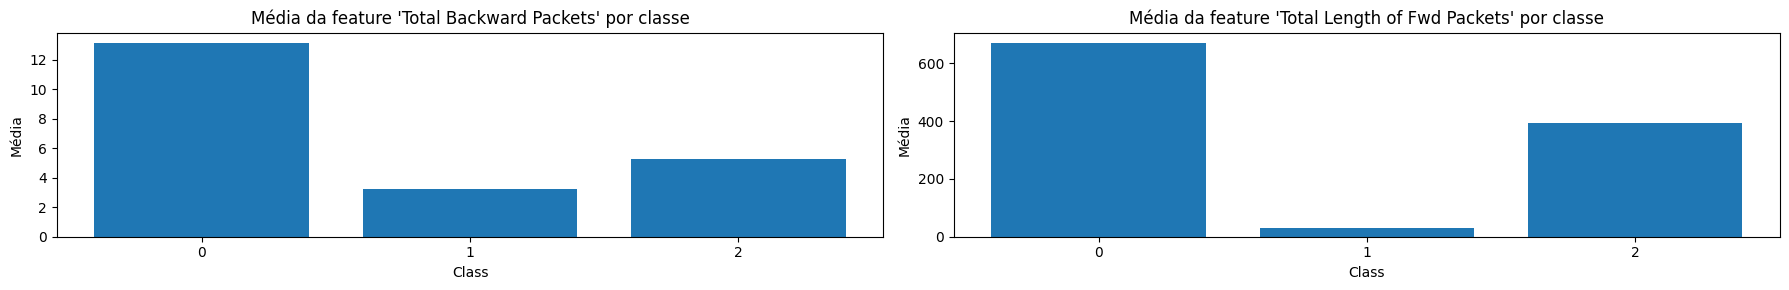

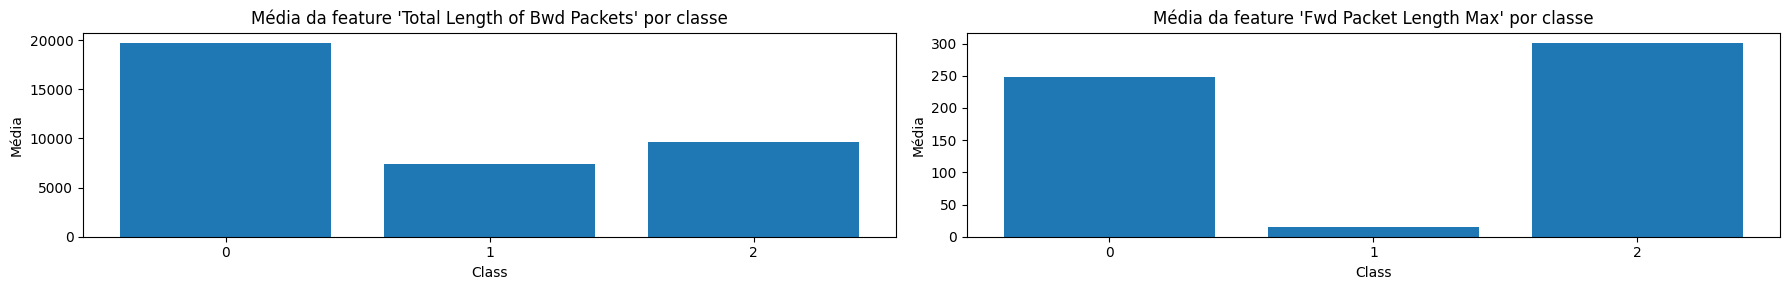

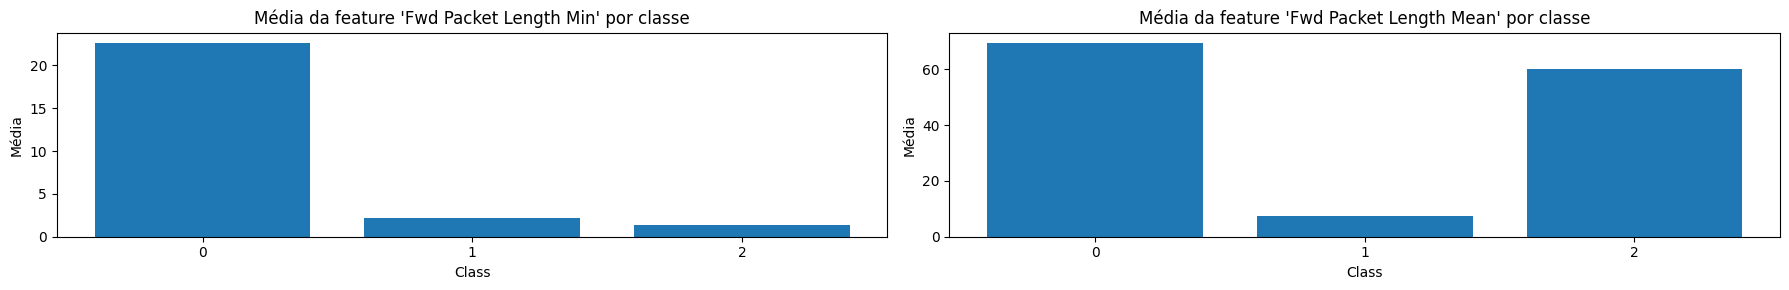

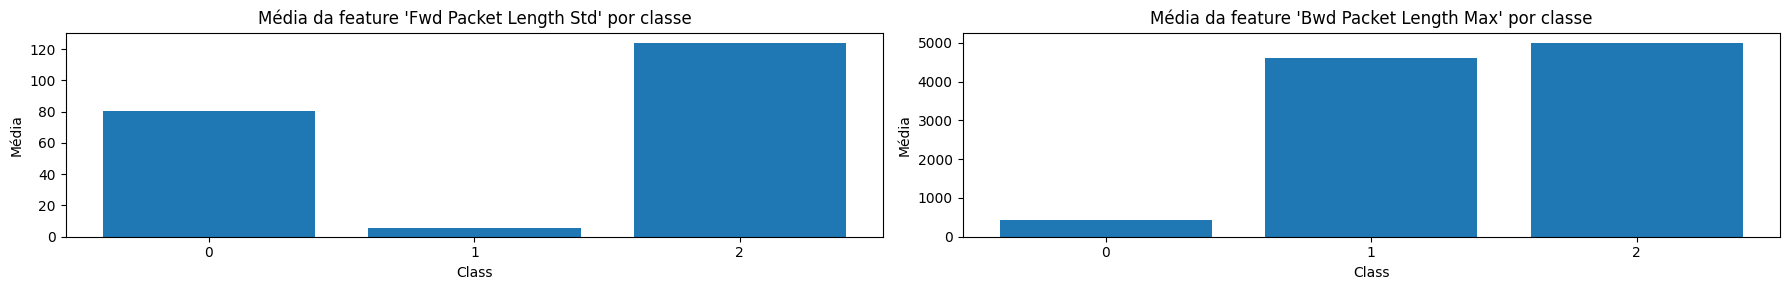

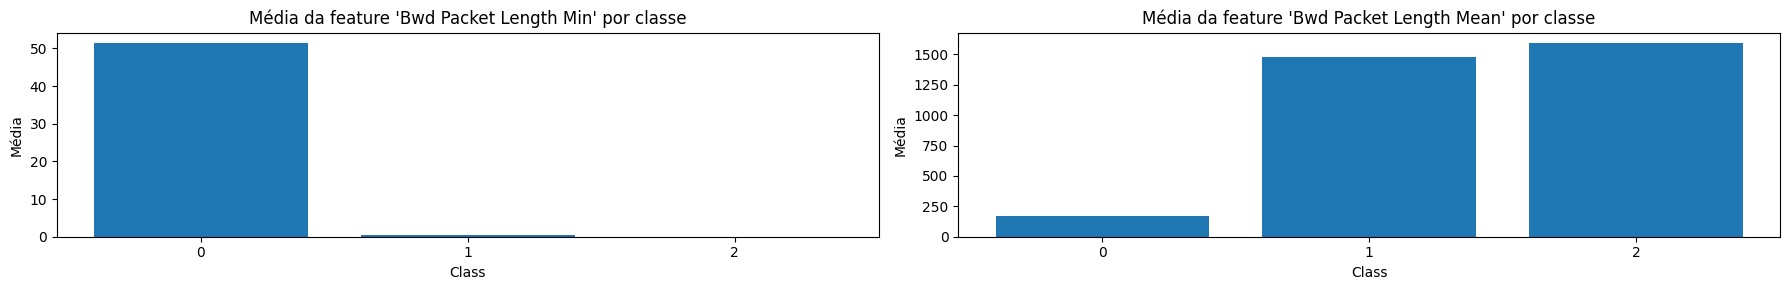

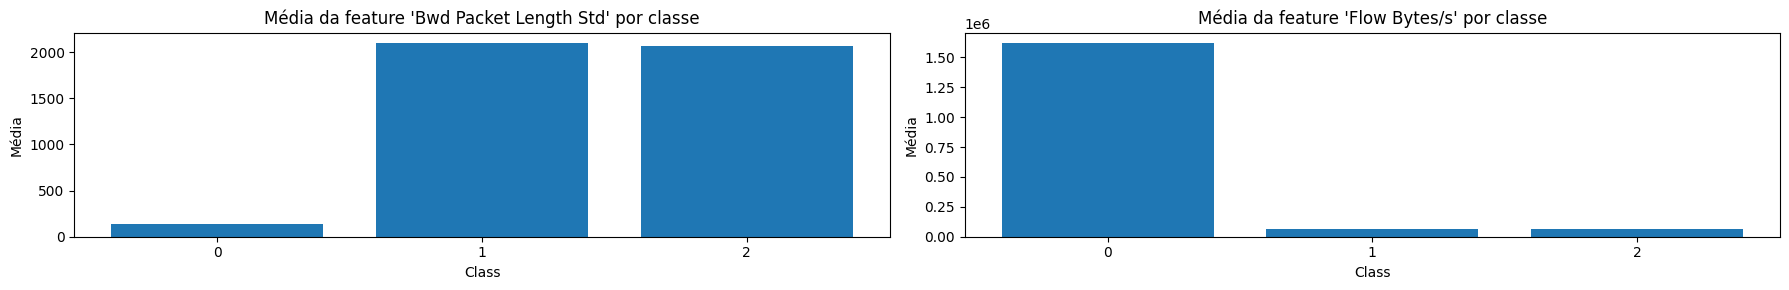

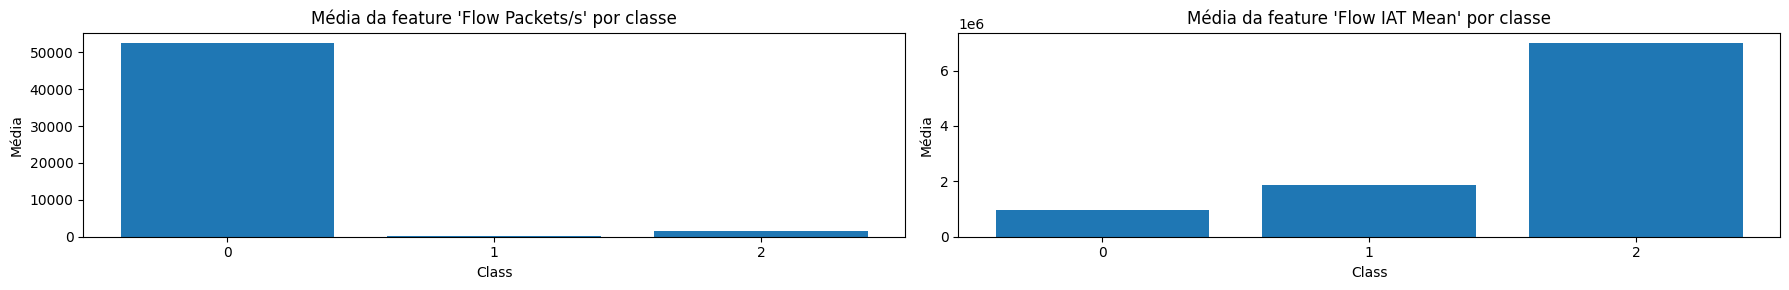

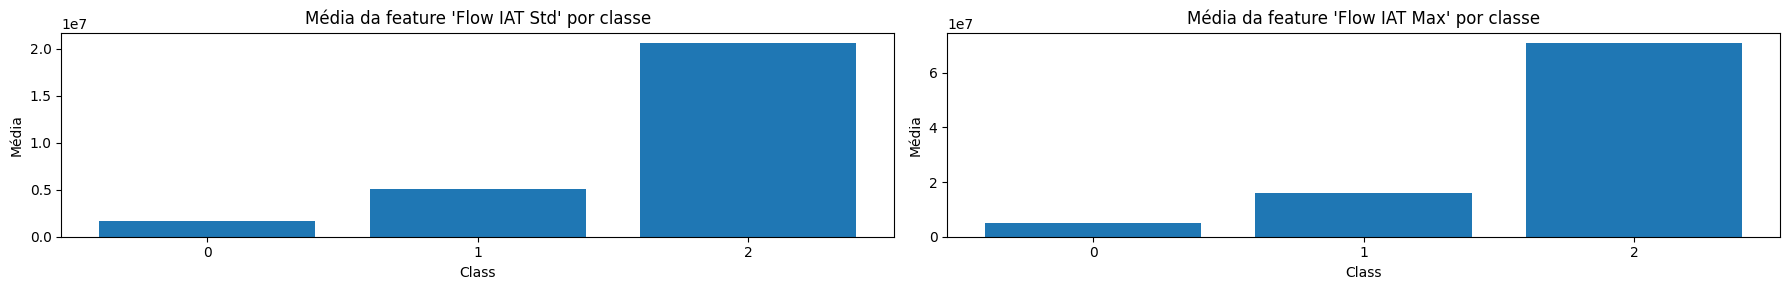

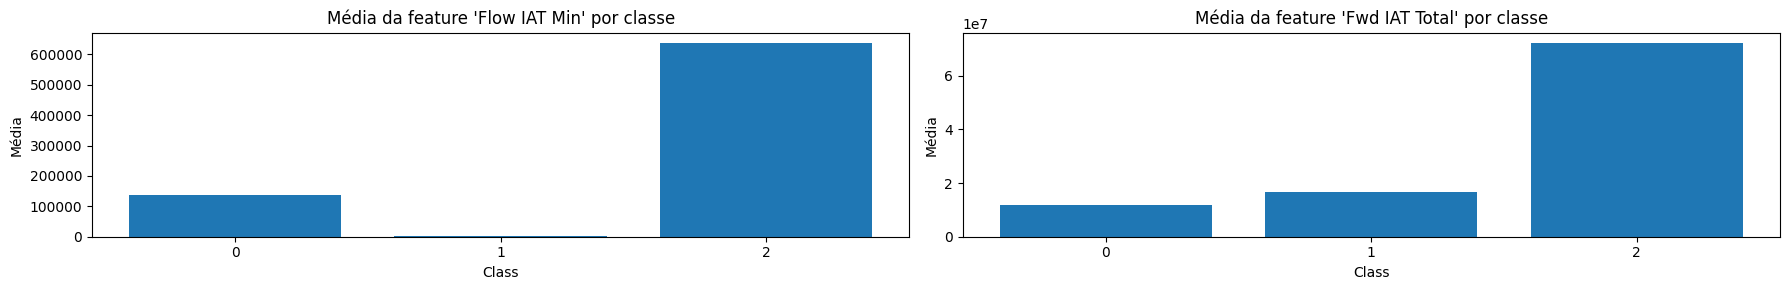

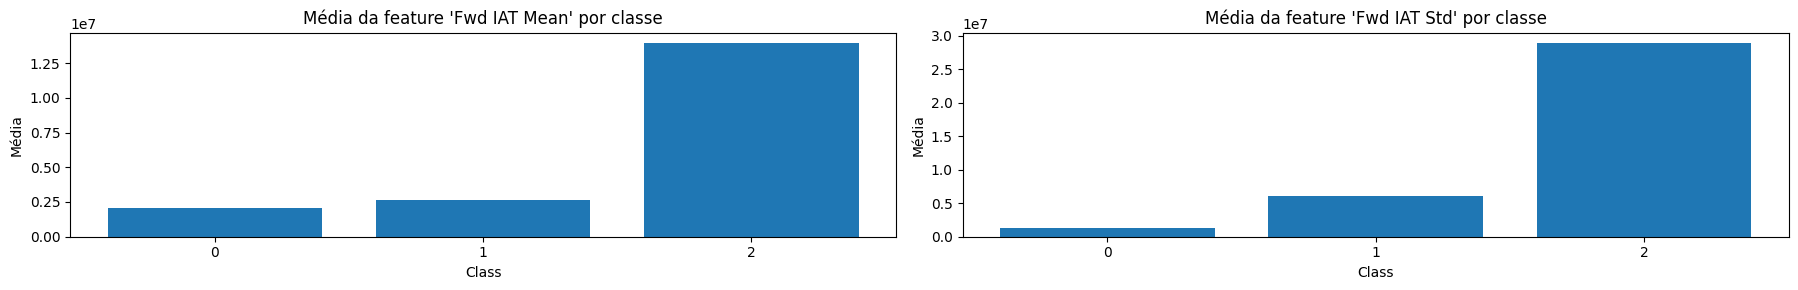

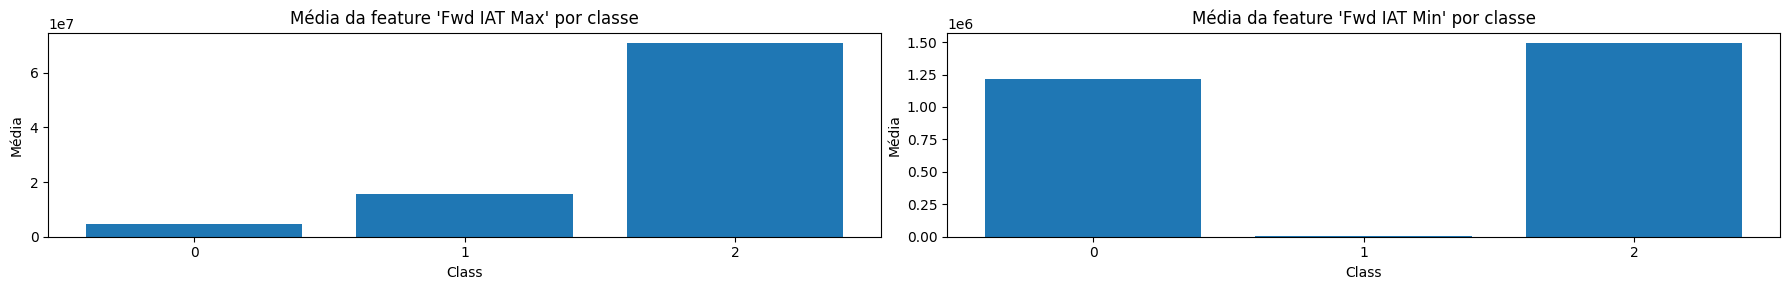

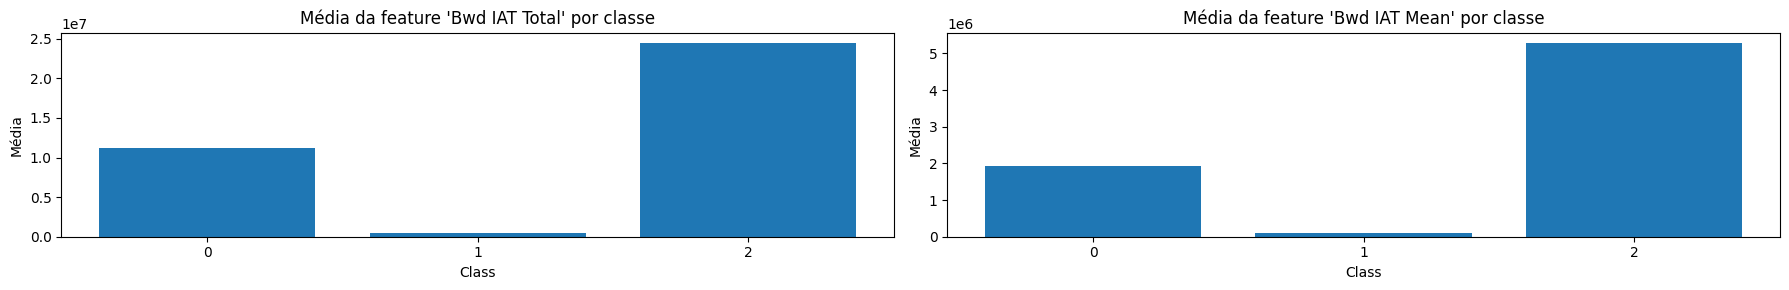

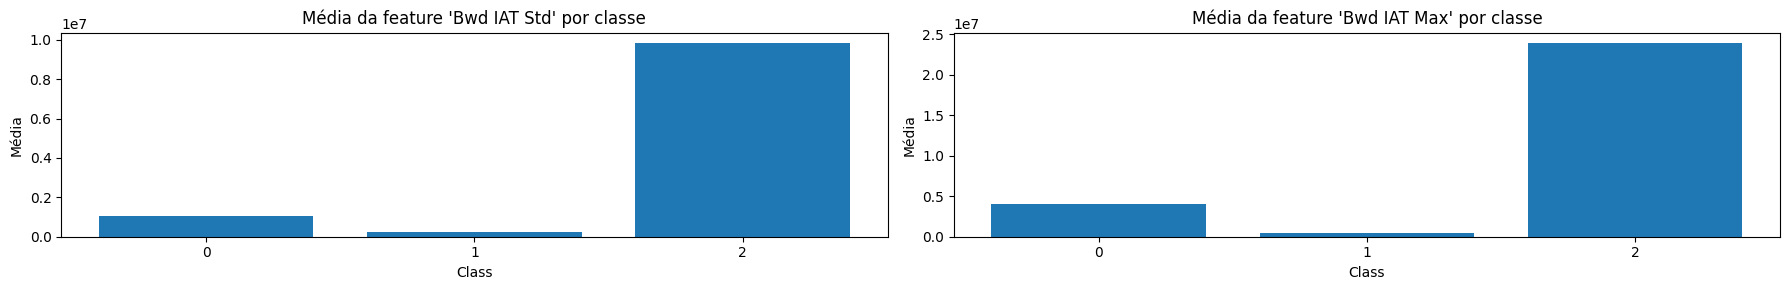

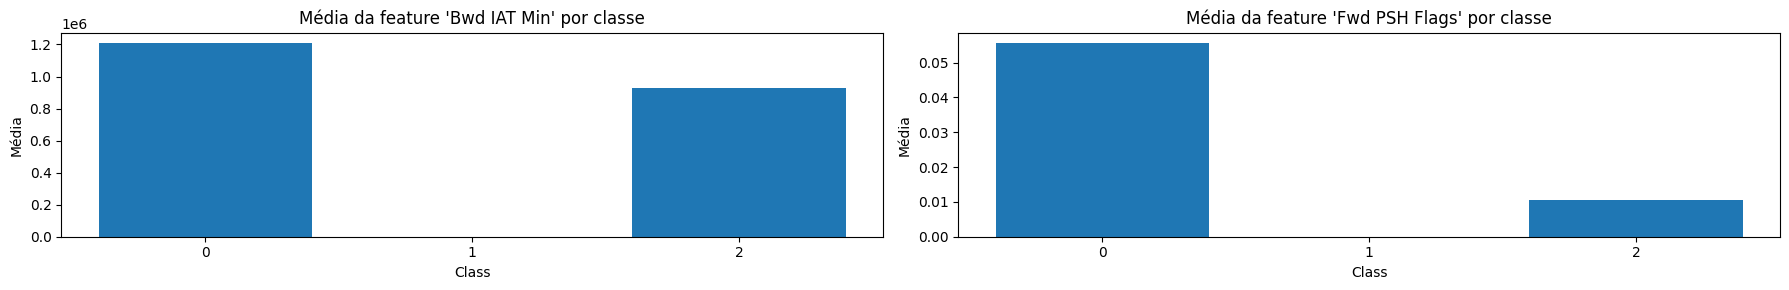

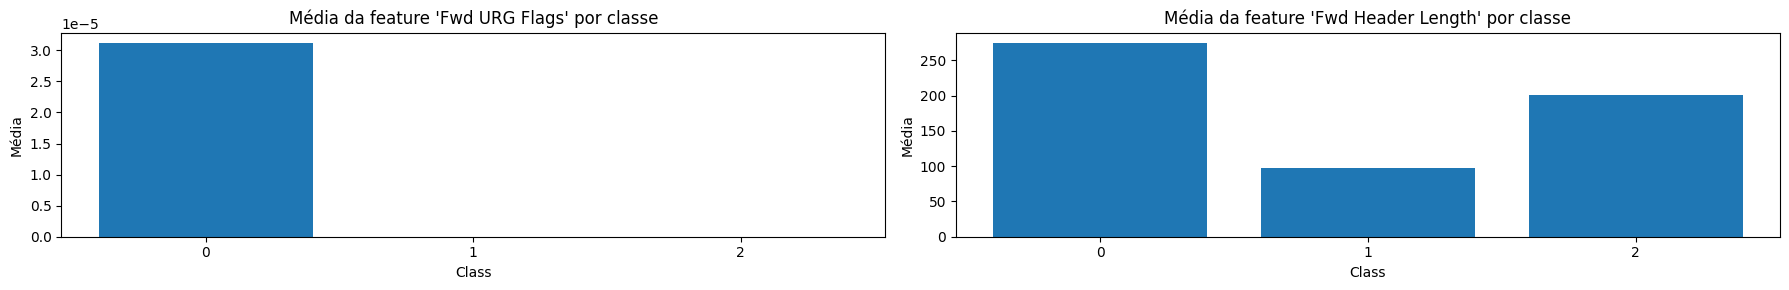

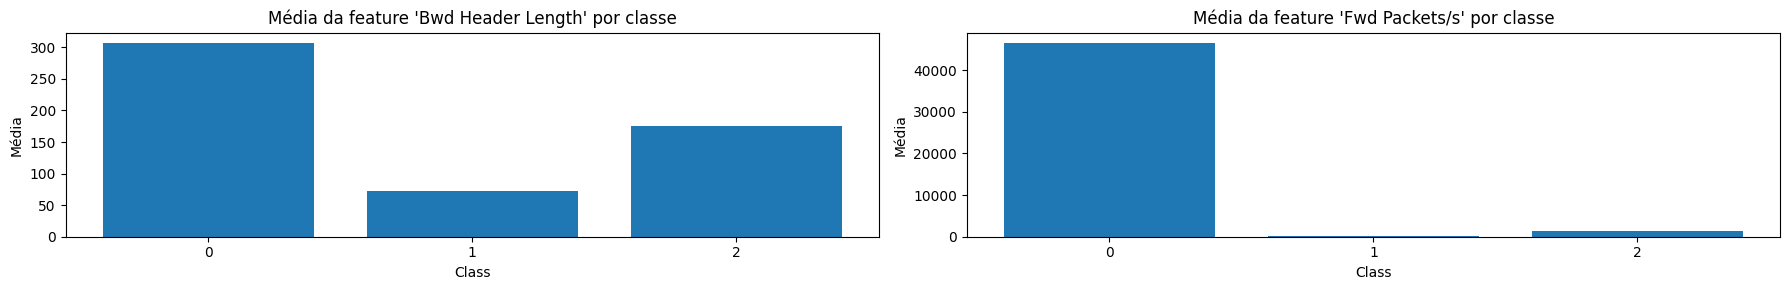

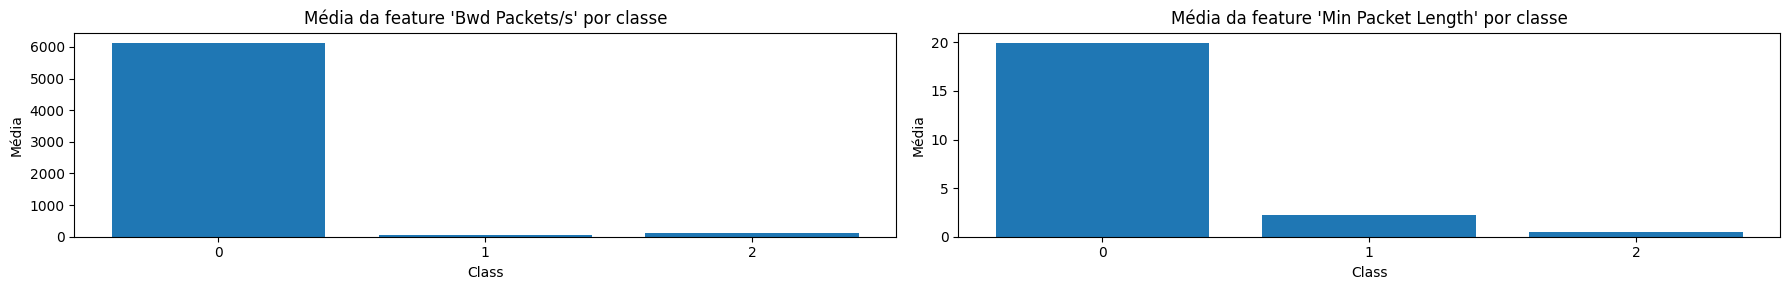

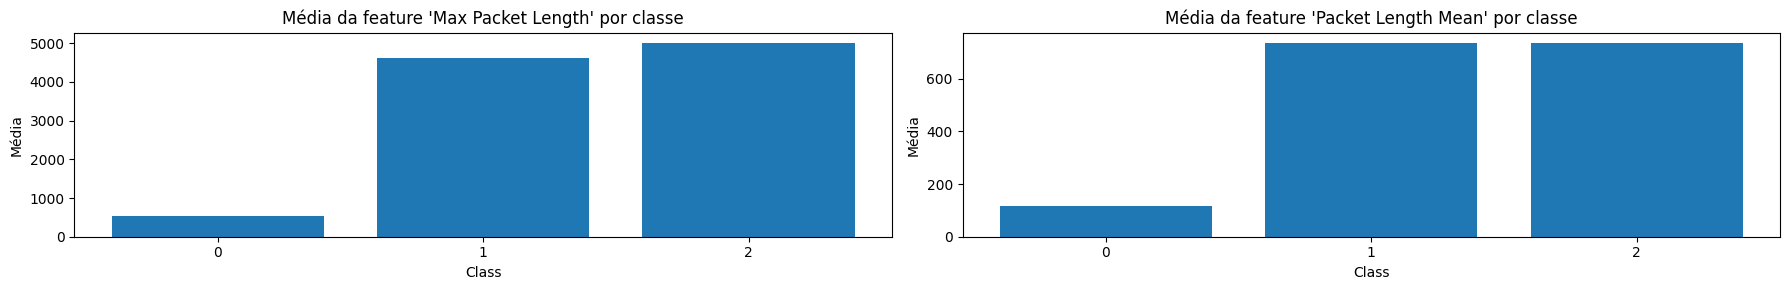

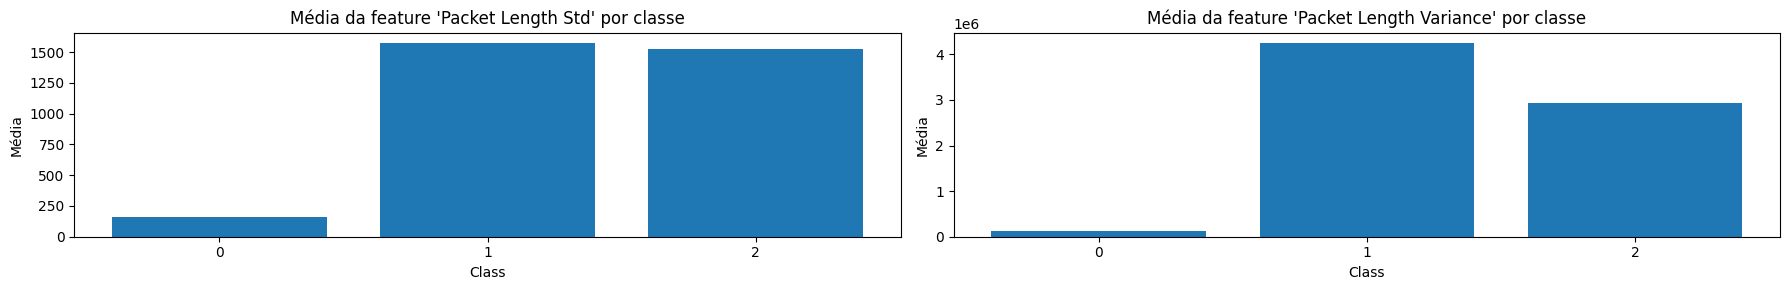

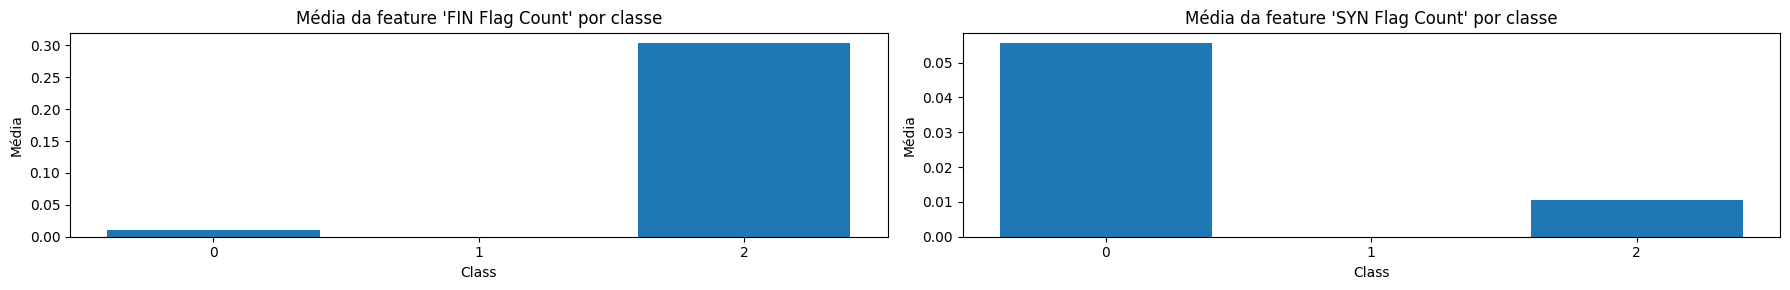

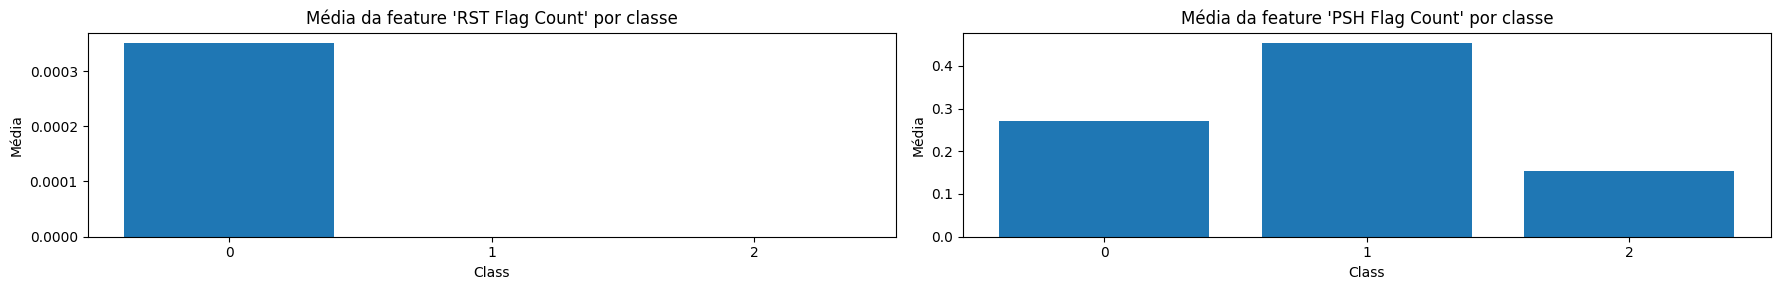

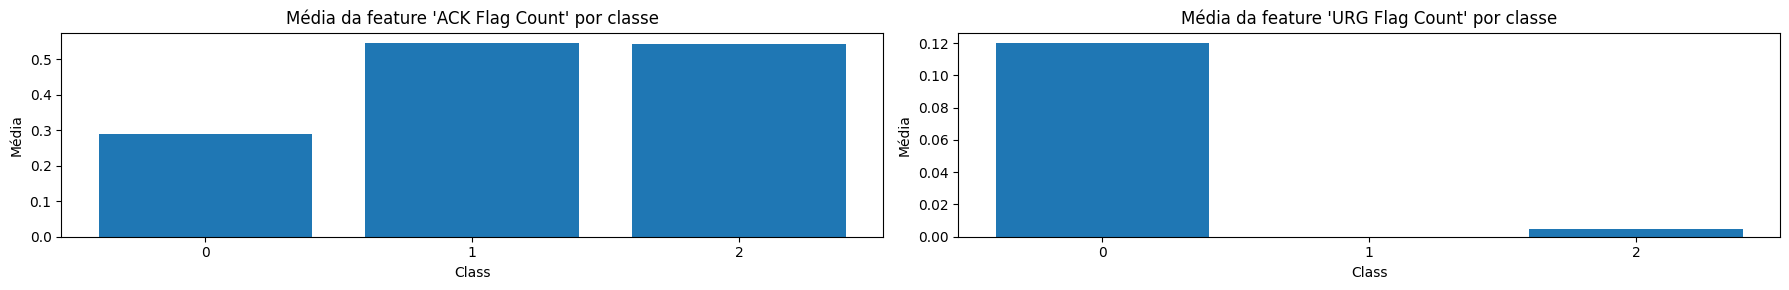

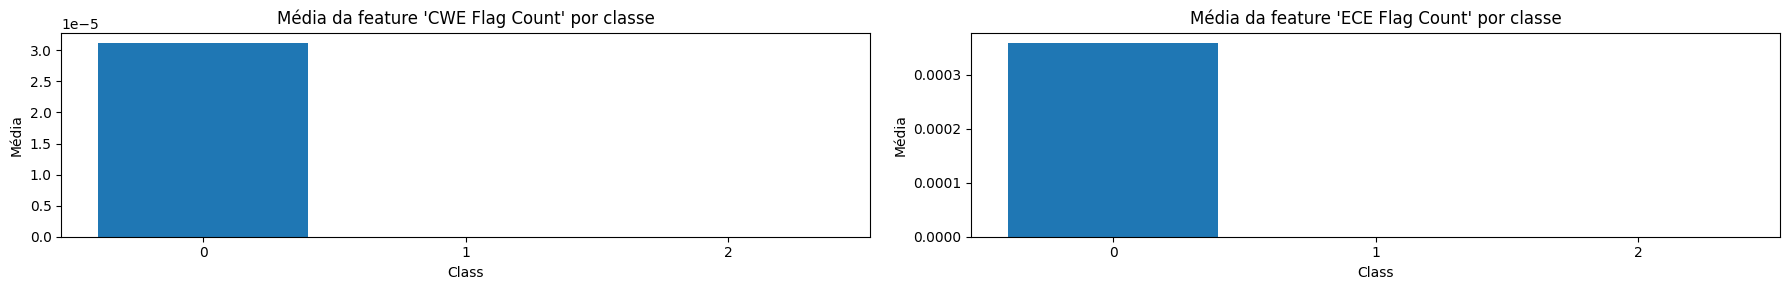

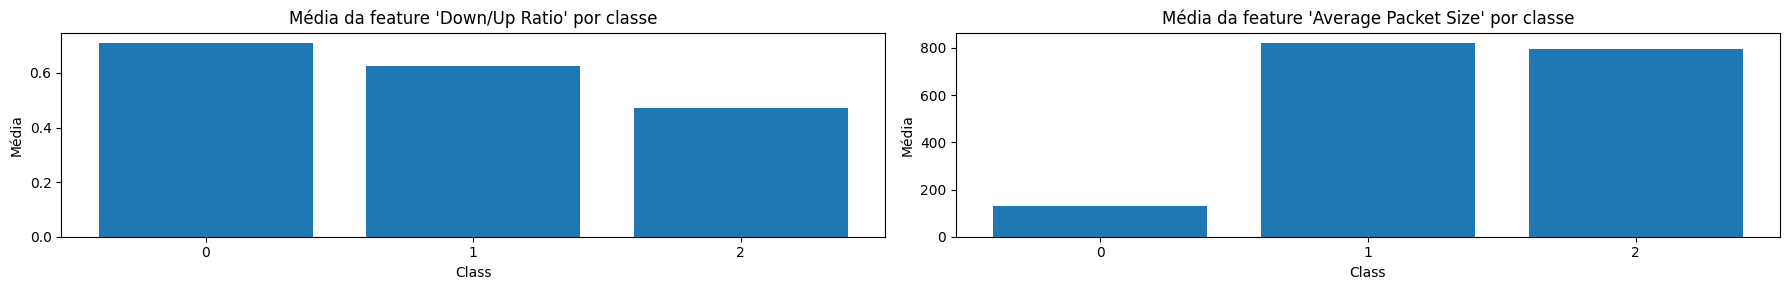

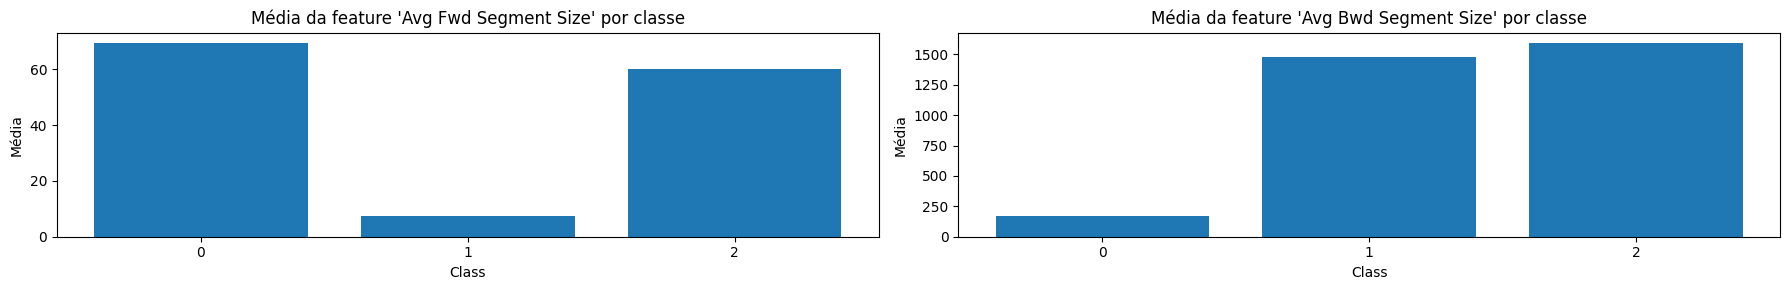

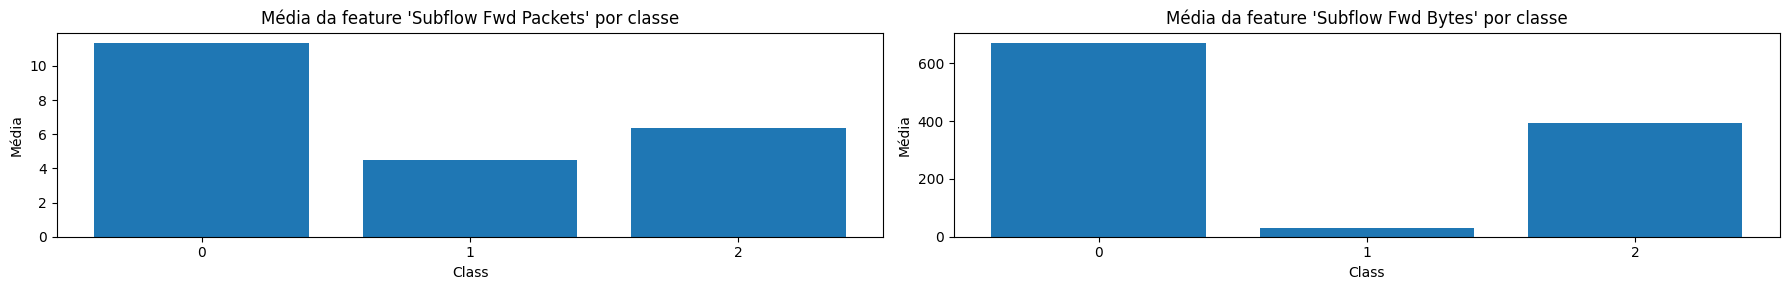

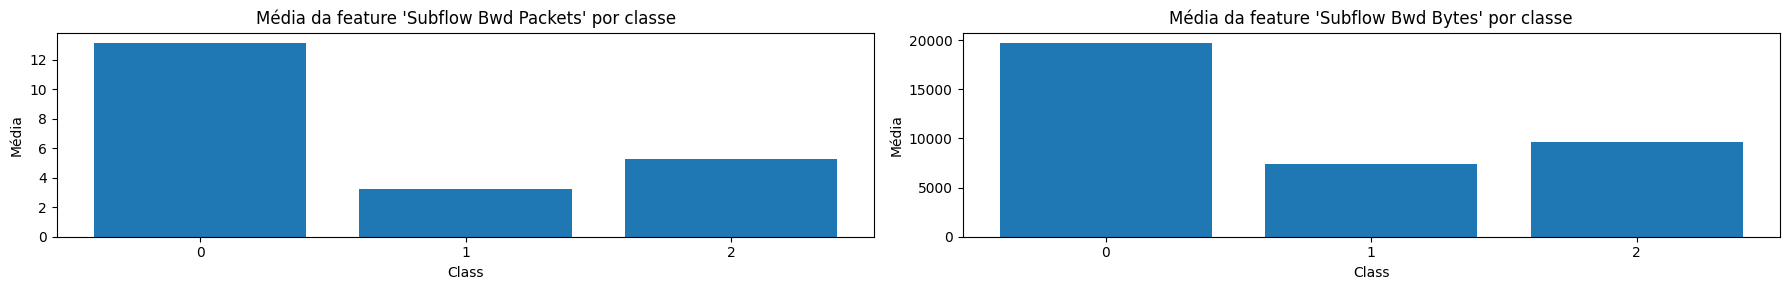

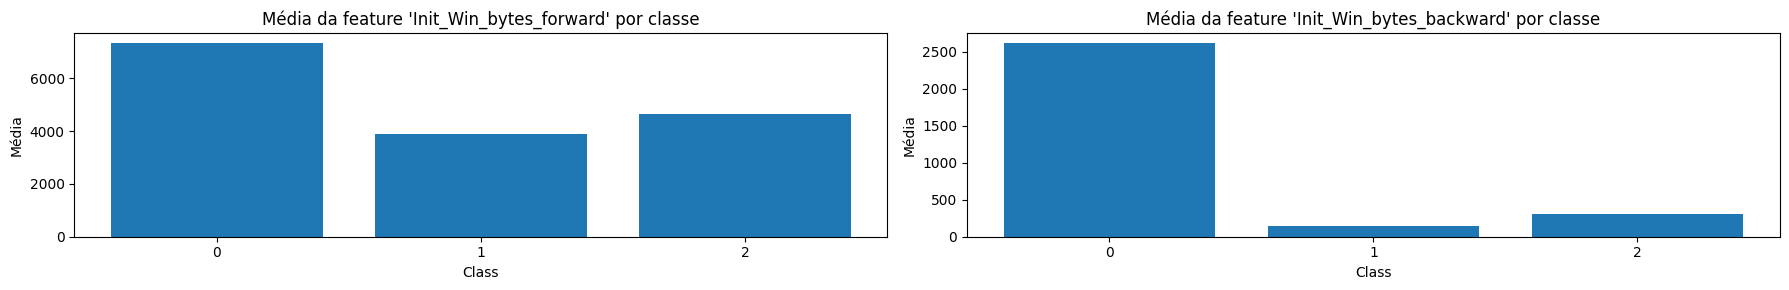

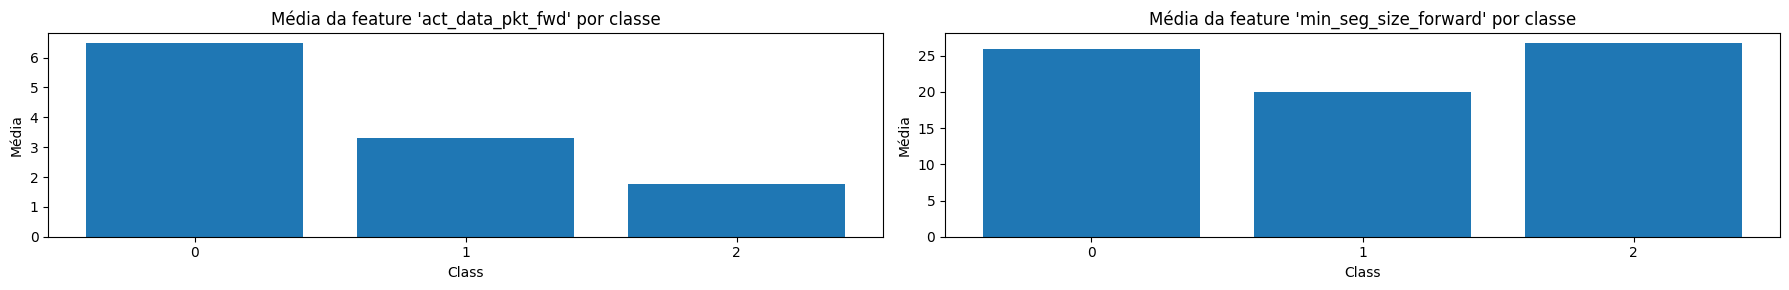

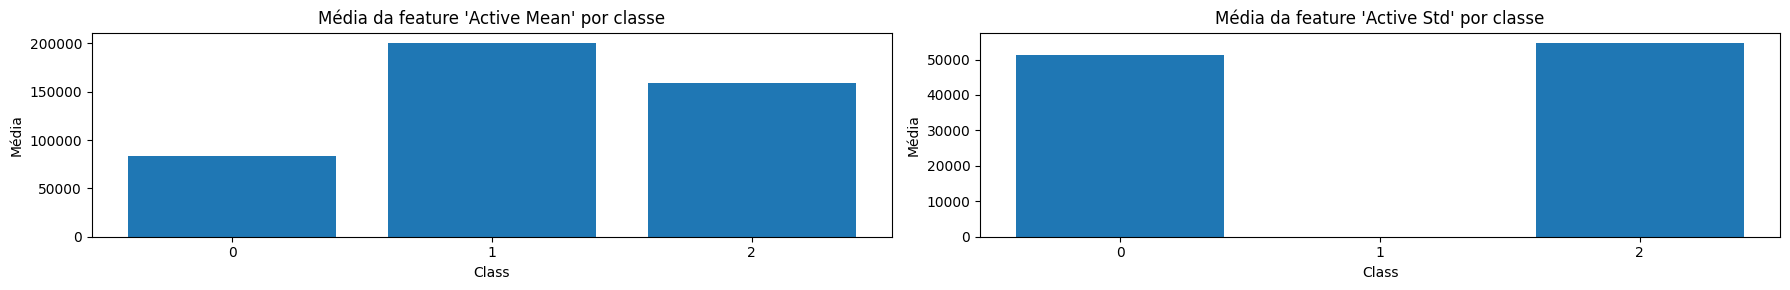

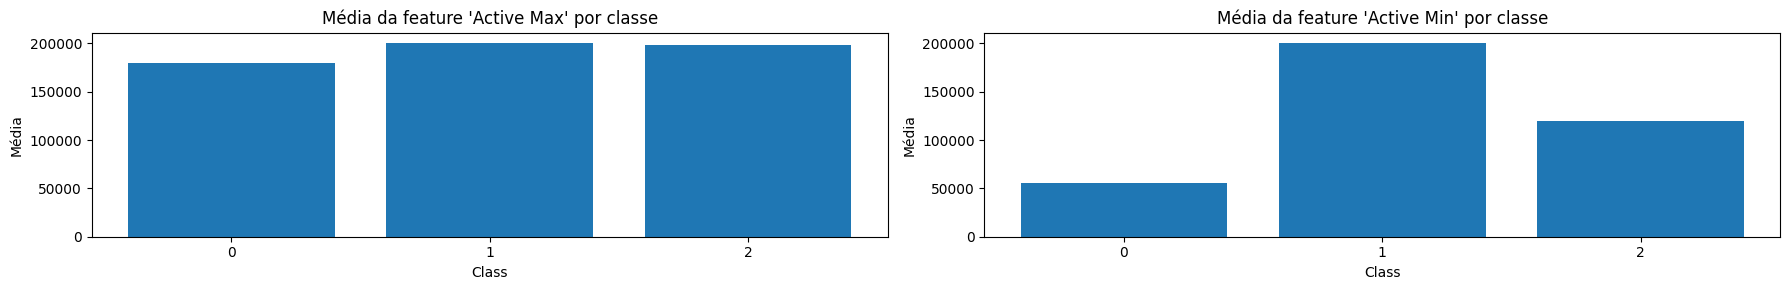

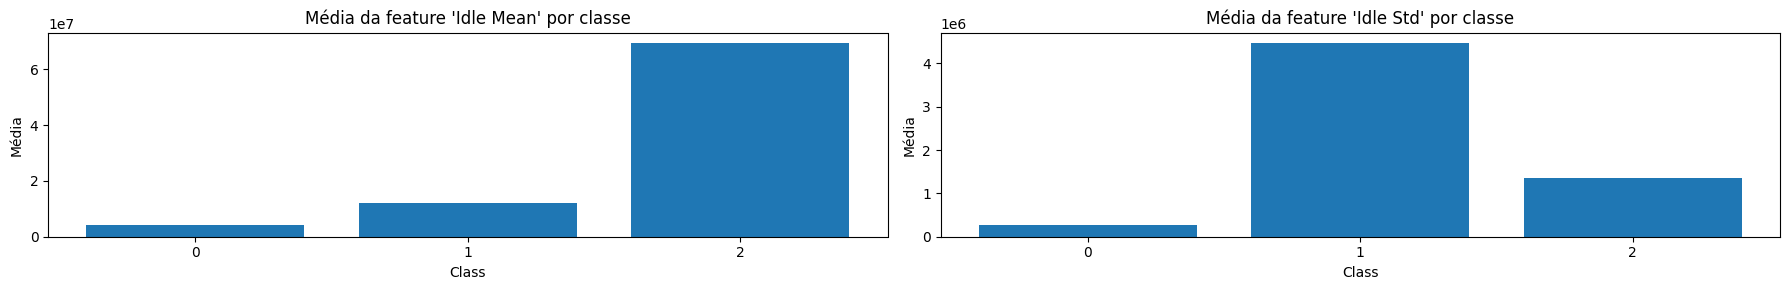

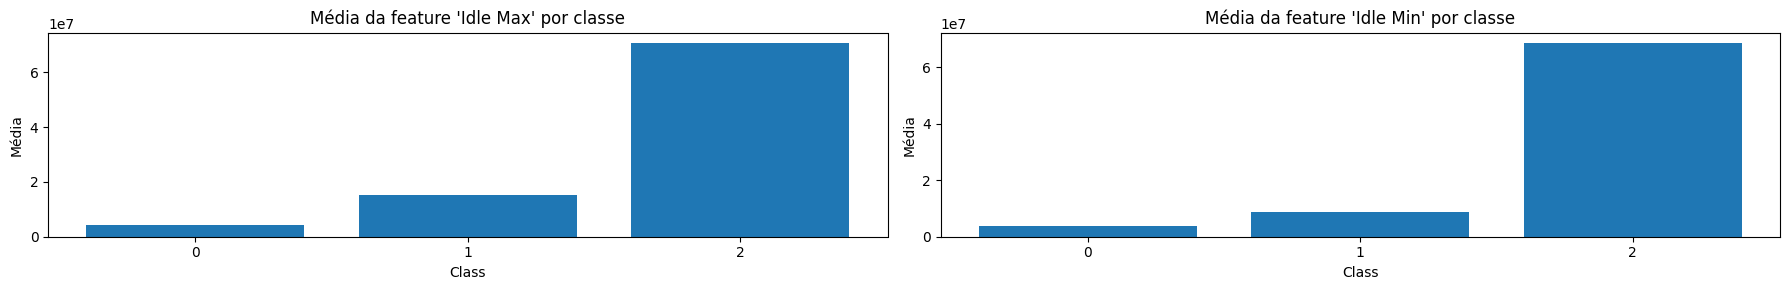

In [52]:
plot_medias_por_classe(df_undersampled, class_col="Class")

# Remoção de Outliers

In [11]:
def remove_outliers_iqr(df, cols, factor=1.5):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

In [12]:
cols_numericas = df_undersampled.select_dtypes(include='number').columns.drop('Class')
df_undersampled_sem_outliers = remove_outliers_iqr(df_undersampled, cols_numericas)

In [36]:
plot_boxplots_por_classe(df_undersampled_sem_outliers, esc_log=True)

NameError: name 'plot_boxplots_por_classe' is not defined

In [37]:
plot_class_distribution(df_undersampled_sem_outliers)

NameError: name 'df_undersampled_sem_outliers' is not defined

# Treinamento

In [38]:
X = df_undersampled.drop(columns=["Class"])
y = df_undersampled["Class"]

In [39]:
X.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,4086069,4,0,24,0,6,6,6.000000,0.000000,0,...,3,20,0.0,0.0,0,0,0.0,0.0,0,0
1,31541,2,2,88,200,44,44,44.000000,0.000000,100,...,1,32,0.0,0.0,0,0,0.0,0.0,0,0
2,84126067,6,6,356,11595,356,0,59.333333,145.336391,4344,...,1,32,5.0,0.0,5,5,84000000.0,0.0,84000000,84000000
3,54,1,1,0,0,0,0,0.000000,0.000000,0,...,0,32,0.0,0.0,0,0,0.0,0.0,0,0
4,30694,1,1,56,112,56,56,56.000000,0.000000,112,...,0,32,0.0,0.0,0,0,0.0,0.0,0,0


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
X_train_scaled.shape

NameError: name 'X_train_scaled' is not defined

In [19]:
#class VerboseRandomForest(RandomForestClassifier):
#    def fit(self, X, y, sample_weight=None):
#        print(f"Iniciando treinamento com {self.n_estimators} árvores...")
#        start = time.time()
#        for i in tqdm(range(self.n_estimators), desc="Treinando árvores"):
#            self.set_params(warm_start=True, n_estimators=i+1)
#            super().fit(X, y, sample_weight)
#        end = time.time()
#        print(f"Treinamento concluído em {end - start:.2f} segundos")
#        return self

In [41]:
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm
import time

randomForest = RandomForestClassifier(random_state=42, n_estimators=100, warm_start=True)
start = time.time()
randomForest.fit(X_train, y_train)
end = time.time()
print(f"Treinamento concluído em {end - start:.2f} segundos")

Treinamento concluído em 94.48 segundos


## Salvamento do Modelo e Scaler

In [58]:
import joblib
import os 

#Cria a pasta modelo caso não exista
os.makedirs("modelo", exist_ok=True)

# Salvar o modelo treinado
joblib.dump(randomForest, "./modelo/random_forest_model.joblib")

# Salvar o LabelEncoder
joblib.dump(label_encoder, "modelo/label_encoder.joblib")

# Salvar o scaler
#joblib.dump(scaler, "modelo/minmax_scaler.joblib")

['modelo/label_encoder.joblib']

## Avaliação do Modelo

In [44]:
y_predict = randomForest.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

def show_classification_metrics(y_true, y_pred):
    print("Acurácia:", accuracy_score(y_true, y_pred))
    print("Precisão:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred))

    # Matriz de confusão gráfica
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.title('Matriz de Confusão')
    plt.show()

def plot_roc_auc(y_true, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR (False Positive Rate)')
    plt.ylabel('TPR (True Positive Rate)')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')
    plt.show()
    print(f'AUC: {auc:.4f}')

Acurácia: 0.99906262205442
Precisão: 0.9990626789938652
Recall: 0.99906262205442
F1 Score: 0.9990626472222899

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25603
           1       1.00      1.00      1.00     25603
           2       1.00      1.00      1.00     25604

    accuracy                           1.00     76810
   macro avg       1.00      1.00      1.00     76810
weighted avg       1.00      1.00      1.00     76810



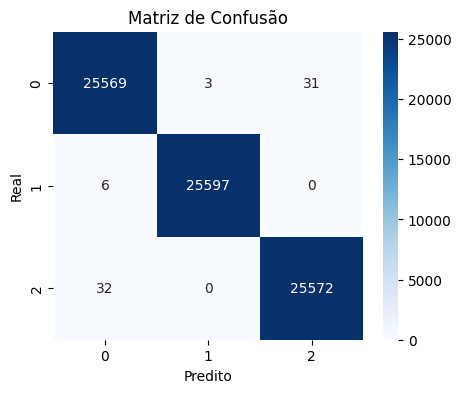

In [46]:
show_classification_metrics(y_test, y_predict)

CSV gerado com sucesso: feature_importances.csv


,feature,importance
0,Fwd Packet Length Max,0.075495
1,Init_Win_bytes_backward,0.067102
2,Subflow Fwd Bytes,0.057568
3,Fwd Packet Length Mean,0.056236
4,Avg Fwd Segment Size,0.047287
5,Total Length of Fwd Packets,0.034212
6,Bwd Packet Length Std,0.033426
7,Fwd IAT Max,0.031648
8,Fwd IAT Std,0.030712
9,Total Fwd Packets,0.028625


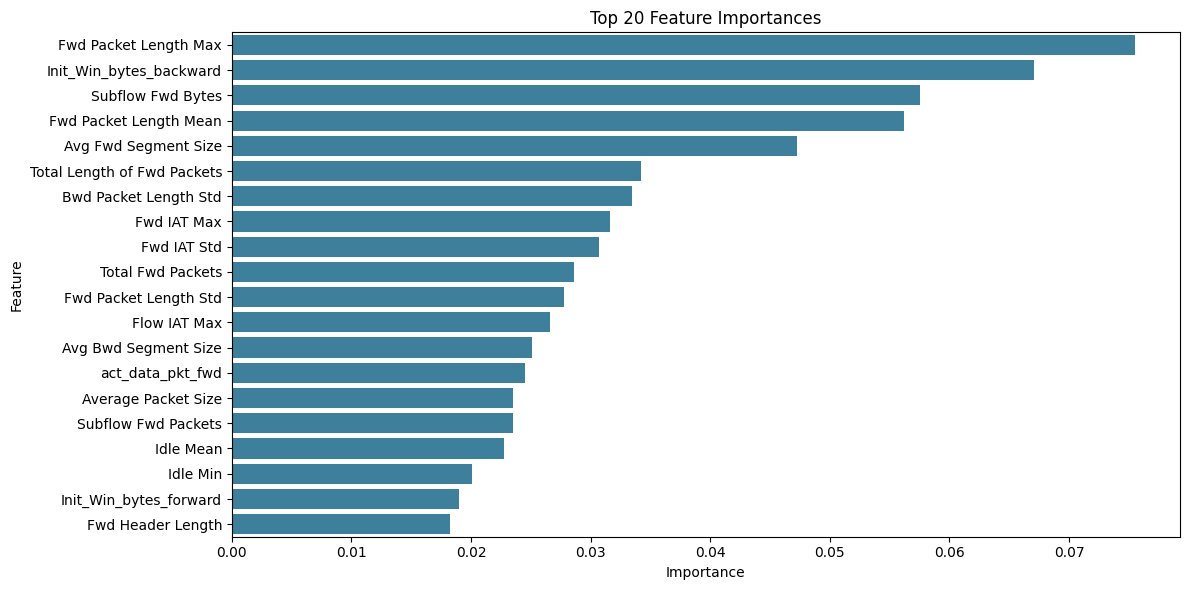

In [49]:
# Feature importance com nomes das colunas + CSV

feature_importances_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": randomForest.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

arquivo_saida = "feature_importances.csv"
feature_importances_df.to_csv(arquivo_saida, index=False, encoding="utf-8-sig")

print(f"CSV gerado com sucesso: {arquivo_saida}")
display(feature_importances_df.head(20))

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importances_df.head(20), x="importance", y="feature", color="#2E86AB")
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [62]:
plot_roc_auc(y_test, y_predict)

ValueError: multiclass format is not supported